# 💎 Diamonds 데이터 분석 캡스톤

본 과제는 Kaggle의 Diamonds 데이터셋을 활용하여 데이터 전처리부터 탐색적 데이터 분석, 통계적 추론, 회귀분석까지 데이터 분석의 전체 흐름을 경험하는 것을 목표로 하는 평가 과제입니다.

아래 미션들은 '정답을 맞히는 과제'가 아니라, '데이터를 통해 하나의 이야기를 만들어 가는 탐구 과제'입니다.

각 미션은 서로 독립적이지만, 모두 합치면 하나의 질문으로 수렴합니다.

이 과제의 목적은 "회귀식=숫자"가 아니라 "회귀식=설명 가능한 세계관" 이라는 인식을 심어주는 데 목적이 있습니다.

In [1]:
from hossam import load_data
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np
import pandas as pd
from pandas import DataFrame
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, pearsonr, spearmanr, probplot, shapiro, kstest, anderson

from statsmodels.formula.api import ols
from statsmodels.stats.api import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
origin=load_data('diamonds')
print('\n===== 데이터 크기 확인 =====')
print(f'데이터셋 크기 : {origin.shape}')
print(f'행 개수 : {origin.shape[0]}개')
print(f'열 개수 : {origin.shape[1]}개')
print('\n===== 타입 확인 =====')
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/kaggle/diamonds.xlsx
[desc] 다이아몬드를 커팅, 색상, 투명도, 가격 및 기타 속성 조사한 데이터 셋 (출처: https://www.kaggle.com/datasets/shivam2503/diamonds)

field    description
-------  -------------------------------------------------------------------
price    다이아몬드 가격 (USD, $326 ~ $18,823)
carat    중량 (0.2~5.01)
cut      컷 품질 (Fair, Good, Very Good, Premium, Ideal)
color    색상 등급 - J (worst) to D (best)
clarity  투명도 등급 (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
x        길이 mm (0~10.74)
y        너비 mm (0--58.9)
z        두께 mm (0--31.8)
depth    비율 정보 = z / mean(x, y) = 2 * z / (x + y) (43--79)
table    다이아몬드의 가장 넓은 지점에 비해 상단(테이블)의 너비 (43--95)


===== 데이터 크기 확인 =====
데이터셋 크기 : (53940, 10)
행 개수 : 53940개
열 개수 : 10개

===== 타입 확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   price    53940 non-null  int64  
 1   carat    

,price,carat,cut,color,clarity,x,y,z,depth,table
0,326,0.23,Ideal,E,SI2,3.95,3.98,2.43,61.5,55.0
1,326,0.21,Premium,E,SI1,3.89,3.84,2.31,59.8,61.0
2,327,0.23,Good,E,VS1,4.05,4.07,2.31,56.9,65.0
3,334,0.29,Premium,I,VS2,4.20,4.23,2.63,62.4,58.0
4,335,0.31,Good,J,SI2,4.34,4.35,2.75,63.3,58.0


In [3]:
my_dpi=200
font_path='../NotoSansKR-Regular.ttf'
fm.fontManager.addfont(font_path)
font_prop=fm.FontProperties(fname=font_path)
font_name=font_prop.get_name()
plt.rcParams['font.family']=font_name
plt.rcParams['font.size']=6
plt.rcParams['axes.unicode_minus']=False

## 🎯미션1. 데이터의 신뢰성 검사 및 전처리

### 1-1) 결측치 검사

In [4]:
# 결측치 검사
origin.isna().sum()

price      0
carat      0
cut        0
color      0
clarity    0
x          0
y          0
z          0
depth      0
table      0
dtype: int64

### 1-2) 다이아몬드의 크기가 0인 기록 제외

In [5]:
# x, y, z 값이 0인 것 제외
df=origin.drop(index=origin[(origin['x']==0) | (origin['y']==0) | (origin['z']==0)].index)
df.count()

price      53920
carat      53920
cut        53920
color      53920
clarity    53920
x          53920
y          53920
z          53920
depth      53920
table      53920
dtype: int64

### 1-3) cut, color, clarity의 범주 확인

In [6]:
# 범주 확인
print('cut_list:',df['cut'].unique())
print('color_list:', df['color'].unique())
print('clarity_list:', df['clarity'].unique())

cut_list: ['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']
color_list: ['E' 'I' 'J' 'H' 'F' 'G' 'D']
clarity_list: ['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']


### 1-4) Box Plot 확인

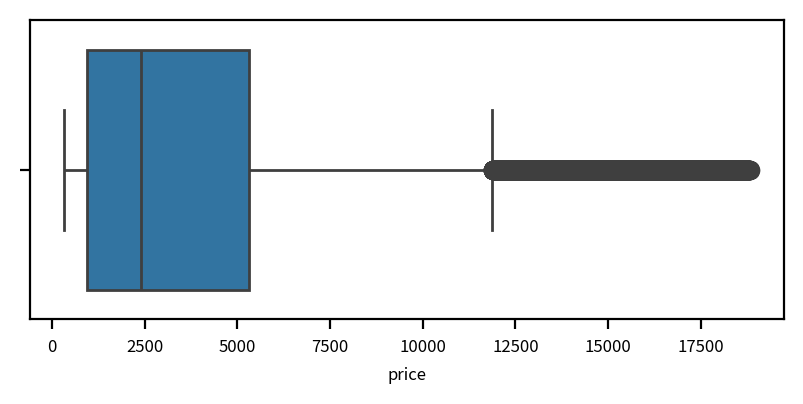

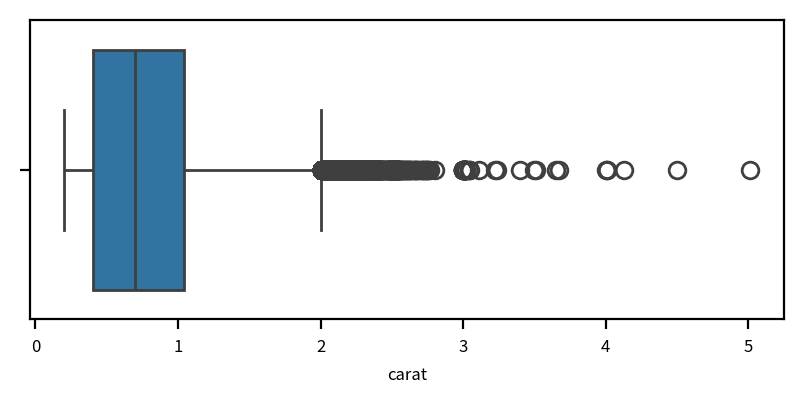

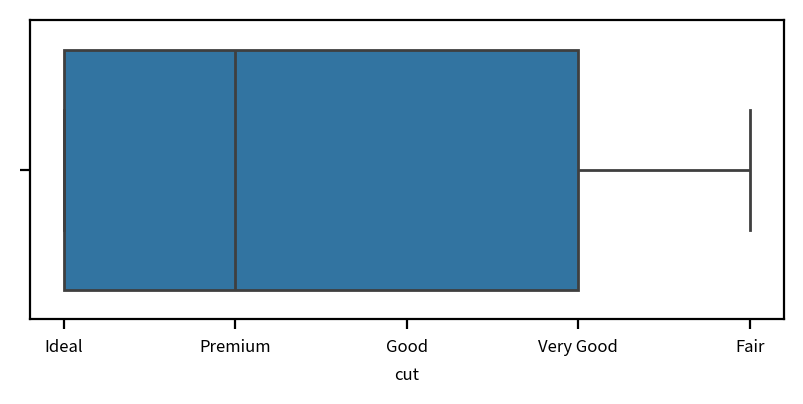

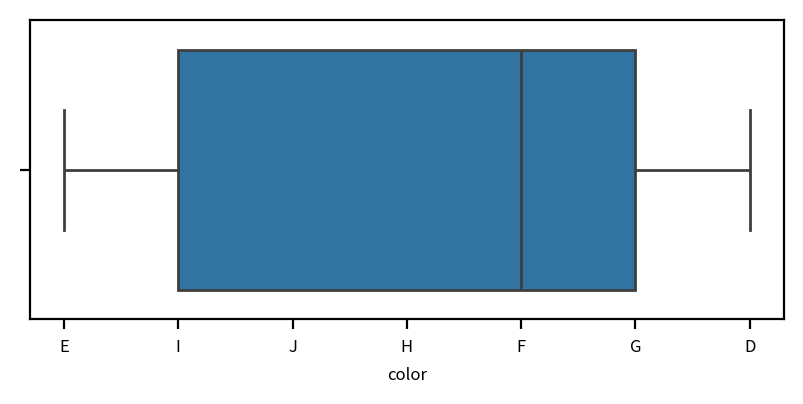

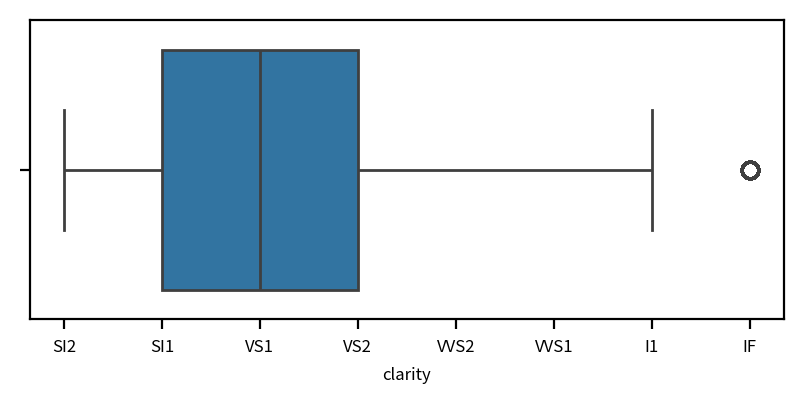

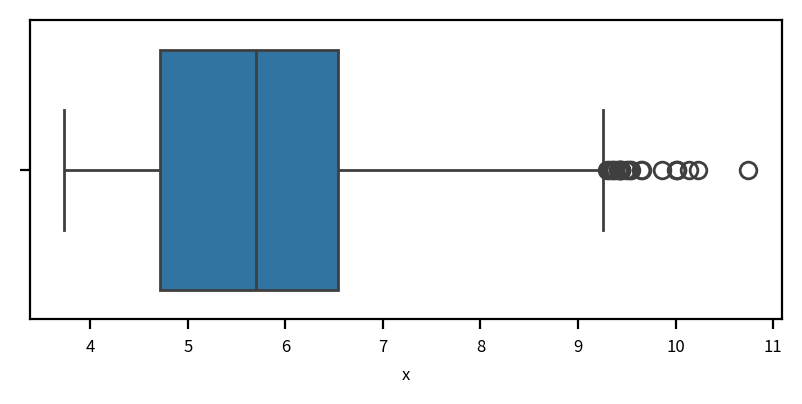

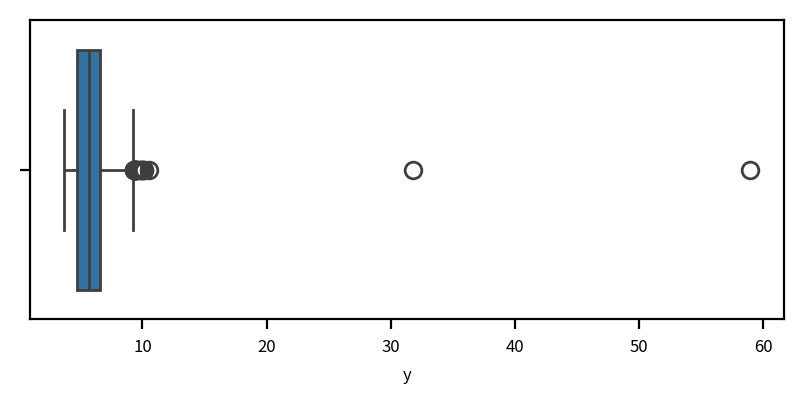

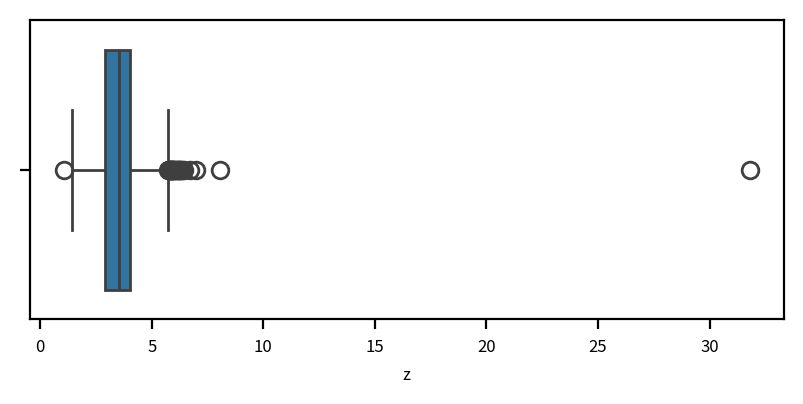

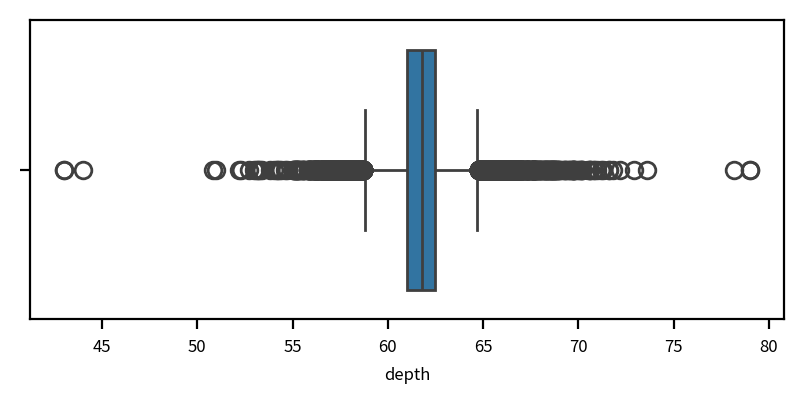

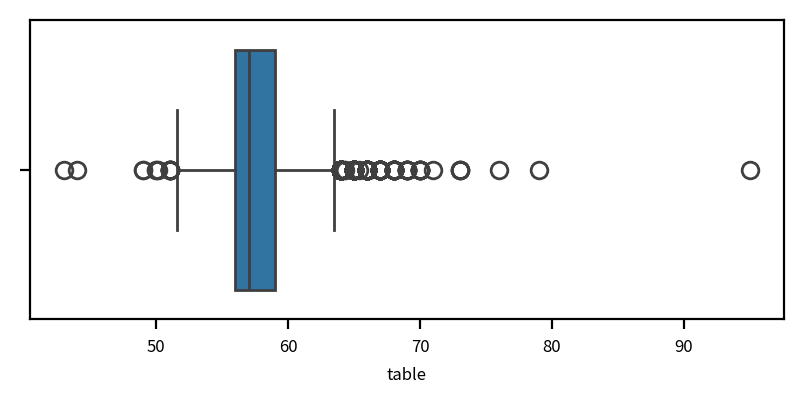

In [7]:
# Box Plot 확인
for i in range(0,len(df.columns)):
    width_px=800
    height_px=400
    rows=1
    cols=1
    figsize=(width_px/my_dpi, height_px/my_dpi)
    fig, ax=plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

    sb.boxplot(data=df, x=df.columns[i])

    plt.tight_layout()
    plt.show()
    plt.close()

### 1-5) 이상치 제거 및 Box Plot 재확인

y값이 30 이상, z값이 30 이상인 것들을 이상치로 판단하고 데이터에서 제거함.

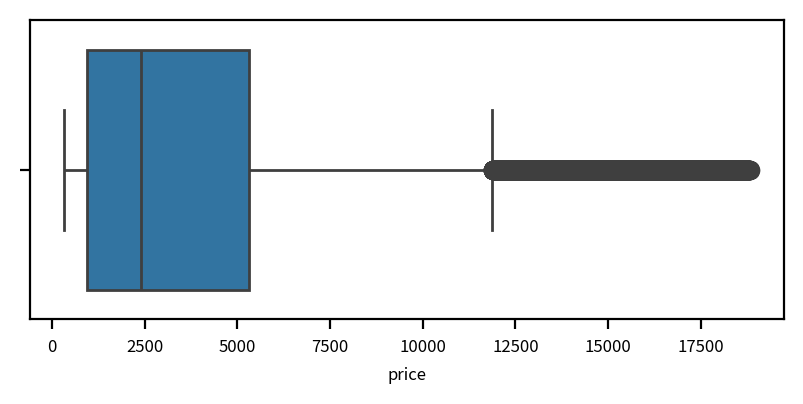

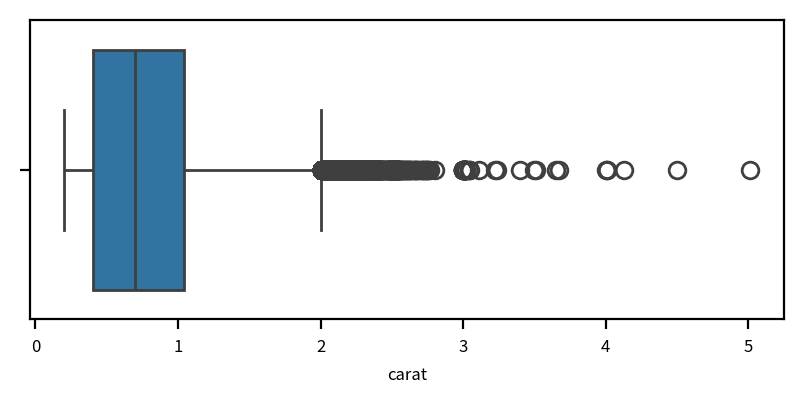

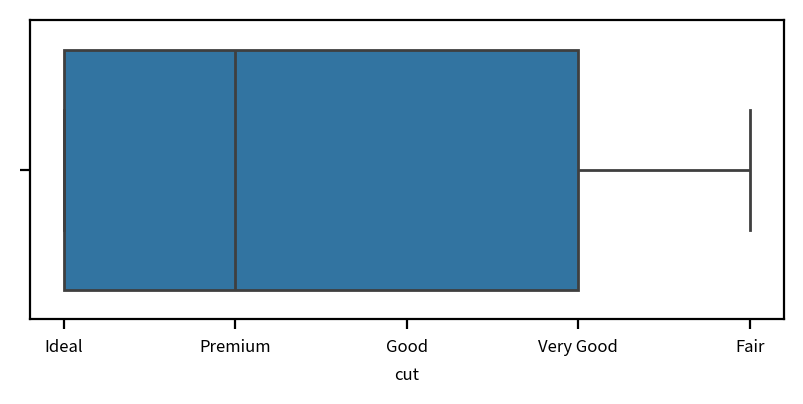

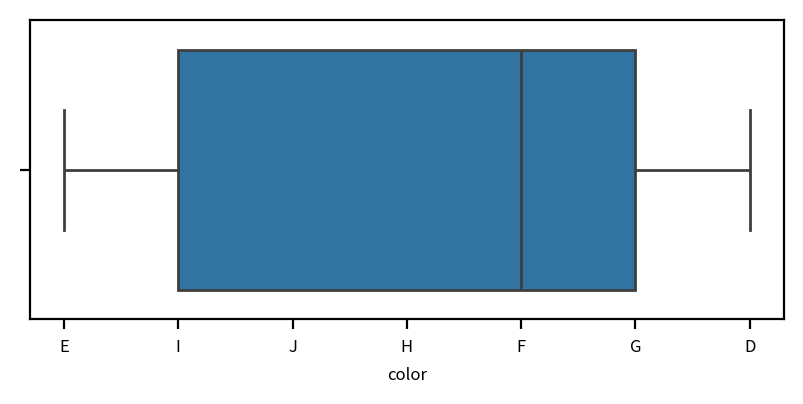

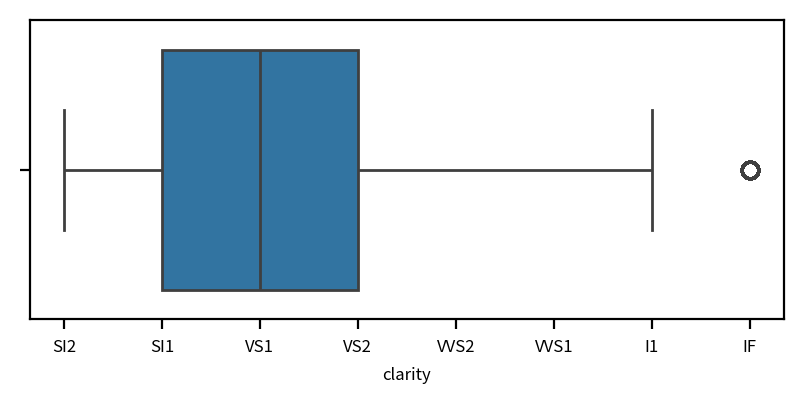

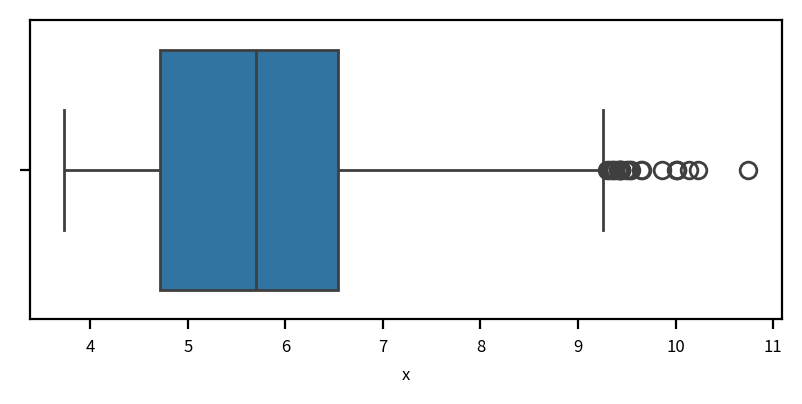

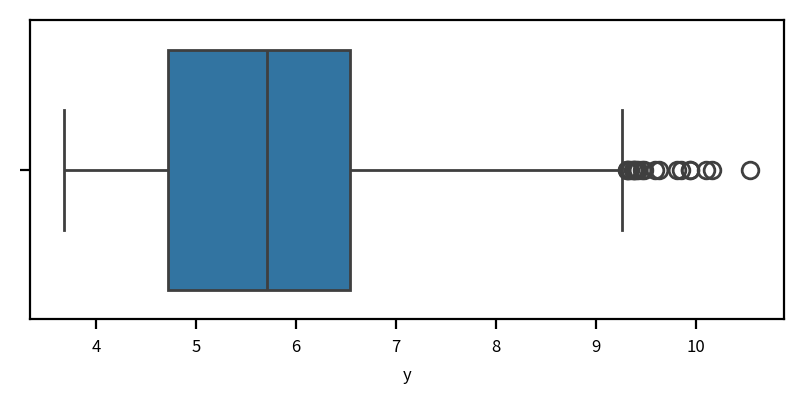

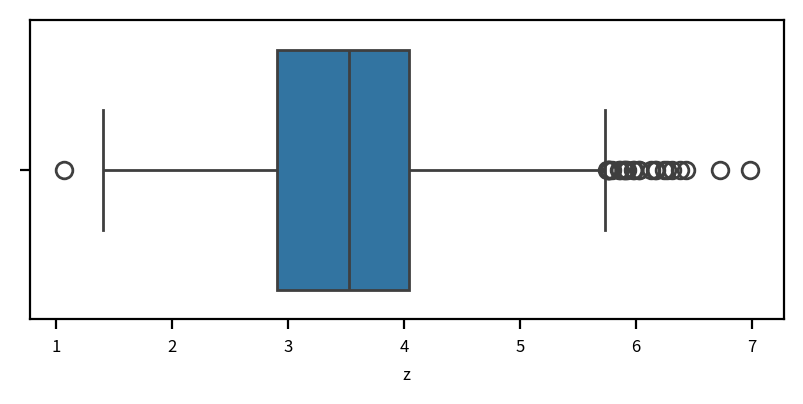

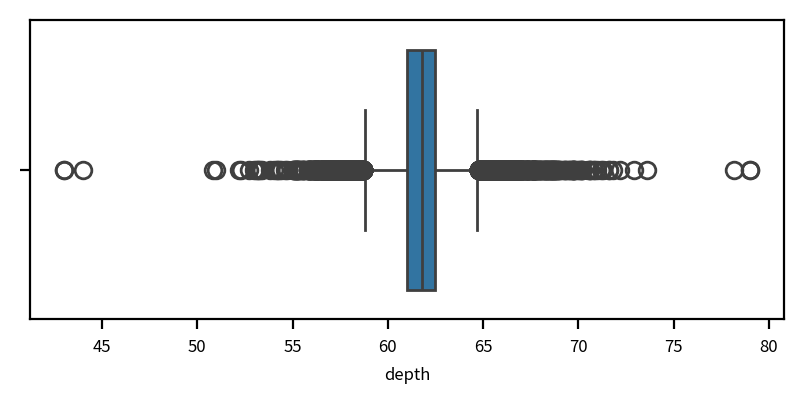

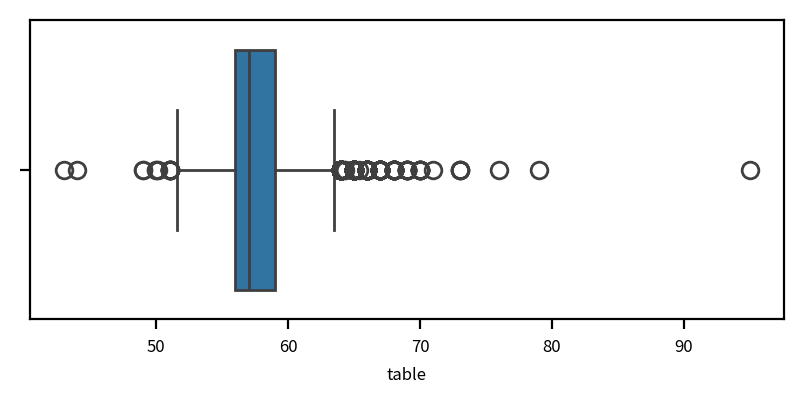

In [8]:
# 이상치 제거 후 BoxPlot 재확인
df1=df.drop(index=df[(df['y']>=30) | (df['z']>=30)].index)
for i in range(0,len(df1.columns)):
    width_px=800
    height_px=400
    rows=1
    cols=1
    figsize=(width_px/my_dpi, height_px/my_dpi)
    fig, ax=plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

    sb.boxplot(data=df1, x=df1.columns[i])

    plt.tight_layout()
    plt.show()
    plt.close()

기존 BoxPlot에서 이상치가 유별나게 특이한 지점을 제거한 후, 다시 BoxPlot을 확인하였음.

## 🎯미션2. 가격 데이터의 분포 파악

### 2-1) Price와 Carat의 KDE Plot 확인

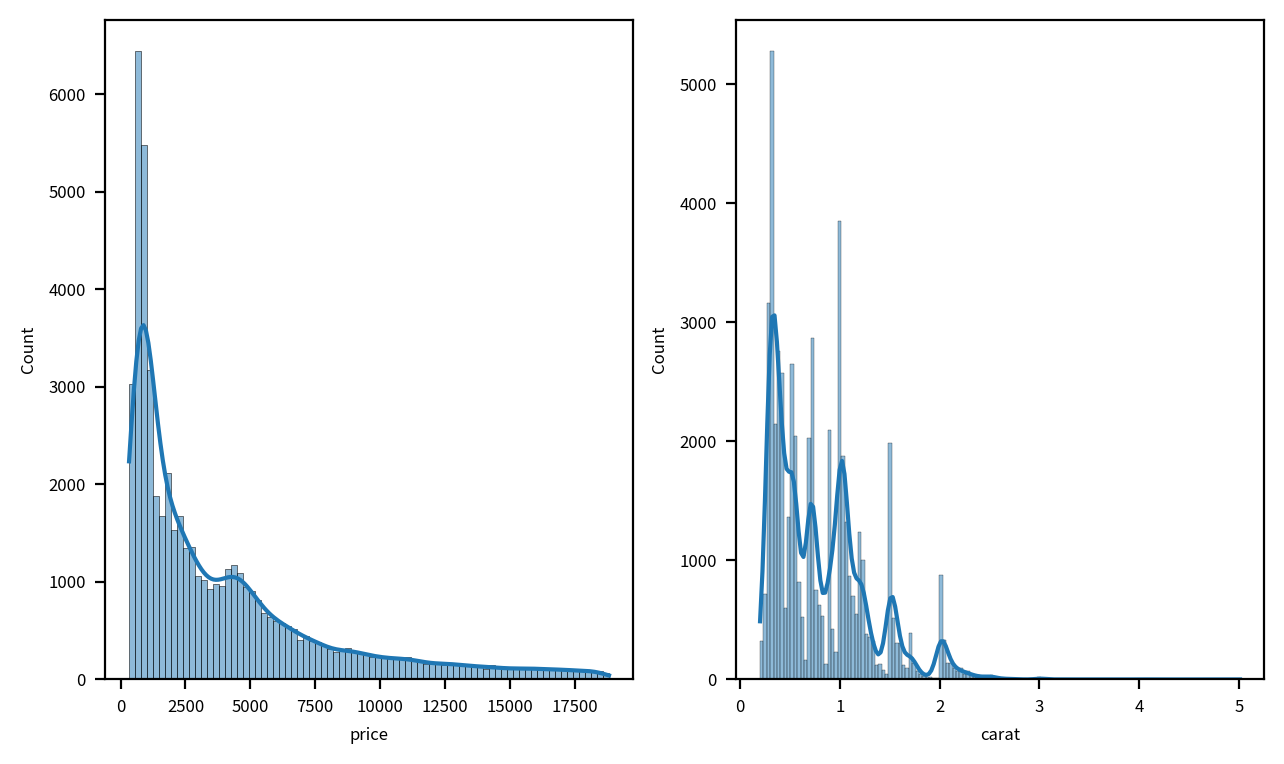

In [9]:
# 1. 그래프 초기화
width_px=1280
height_px=760
rows=1
cols=2
figsize=(width_px/my_dpi, height_px/my_dpi)
fig, ax=plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2. 그래프 그리기
sb.histplot(data=df1, x='price', fill=True, kde=True, ax=ax[0])
sb.histplot(data=df1, x='carat', fill=True, kde=True, ax=ax[1])

# 3. 출력
plt.tight_layout()
plt.show()
plt.close()

price와 carat 변수 모두 분포가 좌편향되어 오른쪽으로 긴 꼬리를 가지고 있다.  
price 변수는 0과 2500 사이에 가장 많은 분포를 가지고 있으며, carat 변수는 0과 1 사이에 여러 개의 봉우리가 나타나고 있다.

### 2-2) 회귀분석 가능 여부 체크

price와 carat 변수 모두 정규성과 거리가 멀고, 데이터가 편향된 모습을 보여주고 있다.  
따라서 이대로 회귀분석을 진행하기 보다는, 전처리를 통해 원하는 데이터의 모양으로 바꾸어주어야 한다.

## 🎯미션3. 가격과 캐럿 데이터의 로그 변환

### 3-1) Price와 Carat의 로그변환 후 KDE Plot 확인

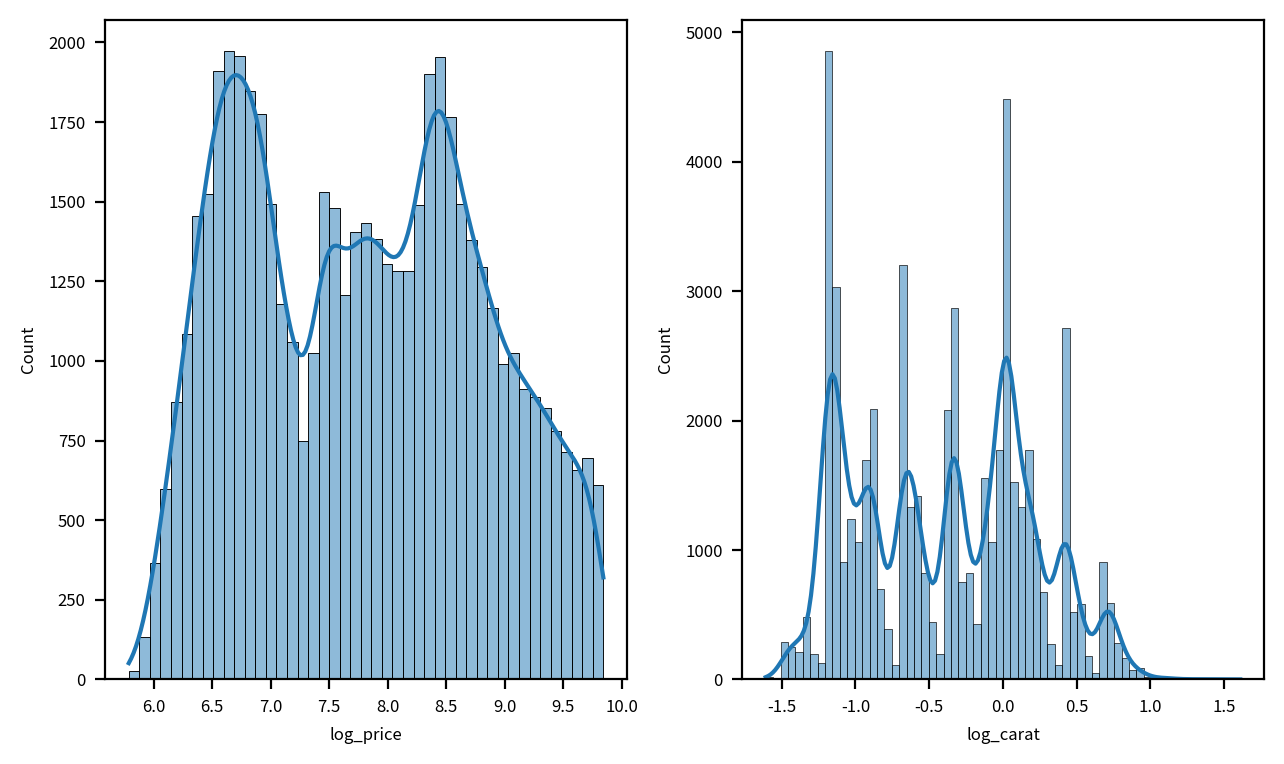

In [10]:
df1['log_price']=np.log(df1['price'])
df1['log_carat']=np.log(df1['carat'])

# 1. 그래프 초기화
width_px=1280
height_px=760
rows=1
cols=2
figsize=(width_px/my_dpi, height_px/my_dpi)
fig, ax=plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2. 그래프 그리기
sb.histplot(data=df1, x='log_price', fill=True, kde=True, ax=ax[0])
sb.histplot(data=df1, x='log_carat', fill=True, kde=True, ax=ax[1])

# 3. 출력
plt.tight_layout()
plt.show()
plt.close()

price와 carat을 각각 로그변환한 log_price와 log_carat의 분포를 보면, 로그변환하기 이전보다 분포가 중심에 더 가까워 졌음을 알 수 있다.  
기존의 데이터보다 중심에 더 가까운 분포를 보여주므로, 기존보다 정규성이 더 확보되었음을 알 수 있다.

## 🎯미션4. 품질 등급에 따른 가격의 분포 확인

### 4-1) 품질 등급에 따른 가격의 중앙값 분포 확인

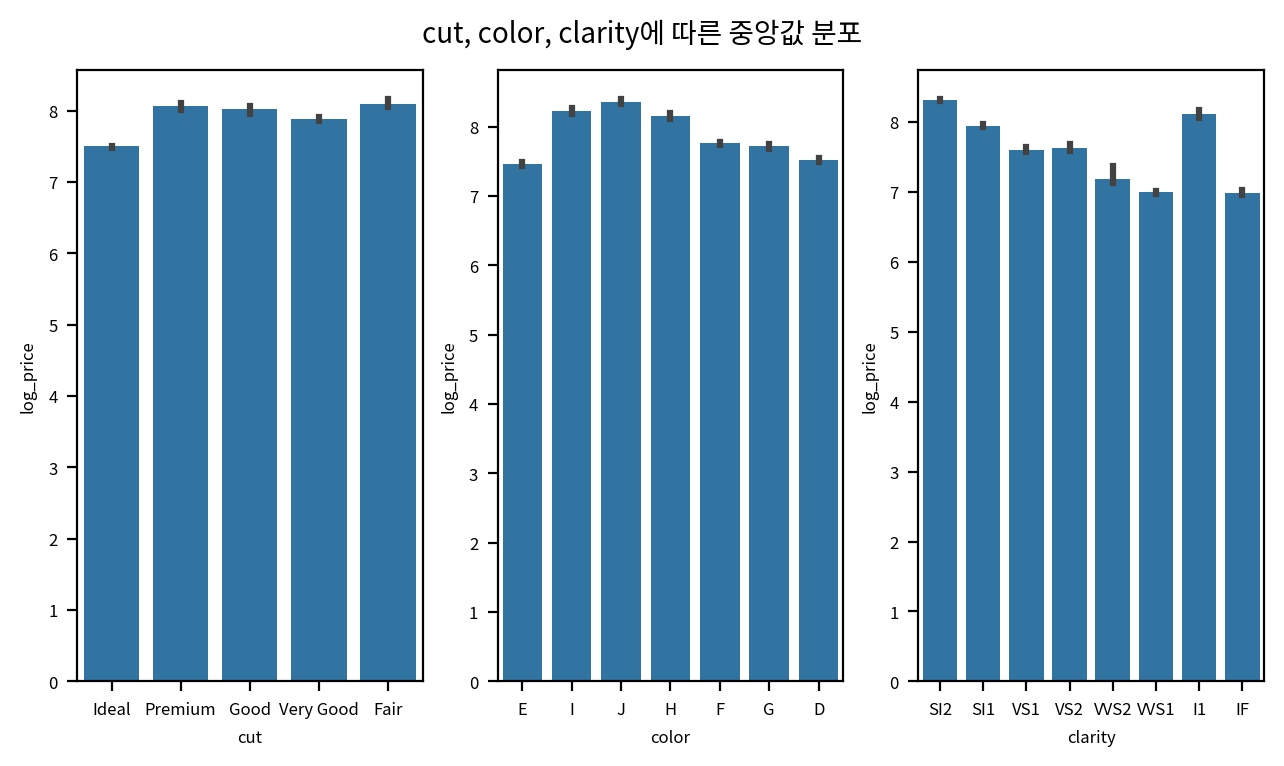

In [11]:
my_list=['cut', 'color', 'clarity']

# 1. 그래프 초기화
width_px=1280
height_px=760
rows=1
cols=3
figsize=(width_px/my_dpi, height_px/my_dpi)
fig, ax=plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2. 그래프 그리기
for i, v in enumerate(my_list):
    sb.barplot(data=df1, x=v, y='log_price', estimator=np.median, ax=ax[i])

fig.suptitle('cut, color, clarity에 따른 중앙값 분포', fontsize=10)

# 3. 출력
plt.tight_layout()
# plt.savefig('myplot.png',dpi=my_dpi)
plt.show()
plt.close()

cut과 color, 그리고 clarity의 중앙값은 등급별로 크게 차이가 나지 않는 것으로 보여지고 있다.

### 4-2) 품질 등급에 따른 가격의 분산 분포 확인

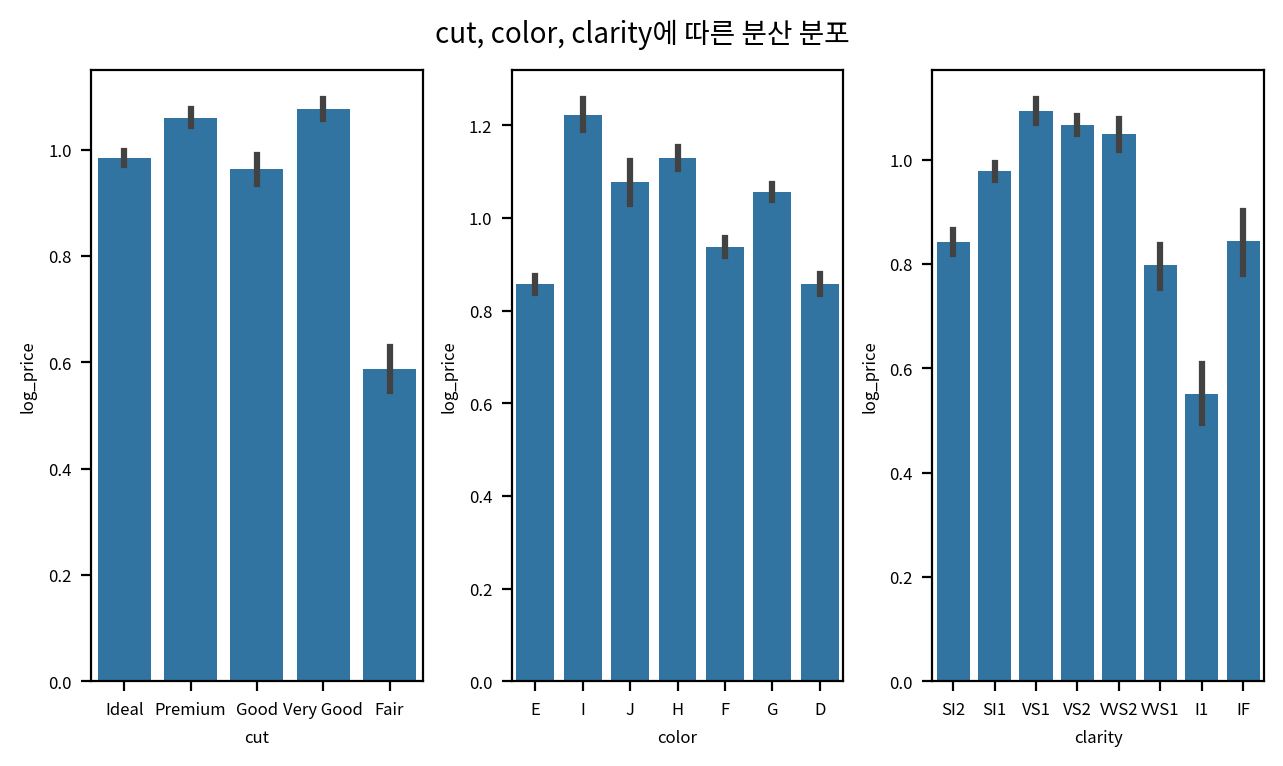

In [12]:
# 1. 그래프 초기화
width_px=1280
height_px=760
rows=1
cols=3
figsize=(width_px/my_dpi, height_px/my_dpi)
fig, ax=plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2. 그래프 그리기
for i, v in enumerate(my_list):
    sb.barplot(data=df1, x=v, y='log_price', estimator=np.var, ax=ax[i])

fig.suptitle('cut, color, clarity에 따른 분산 분포', fontsize=10)

# 3. 출력
plt.tight_layout()
# plt.savefig('myplot.png',dpi=my_dpi)
plt.show()
plt.close()

cut과 color, 그리고 clarity의 분산은 등급별로 차이를 조금씩 보이고 있다.  
특히 cut의 Fair와 clarity의 l1 등급이 뚜렷하게 분산이 작은 모습을 보여주고 있다.  
하지만 이러한 점으로 인해 cut과 color, 그리고 clarity가 "가격"을 좌우하는 요소라고 판단하기는 어렵다.

## 🎯미션5, 6. Cut에 대한 Price의 일원분산분석

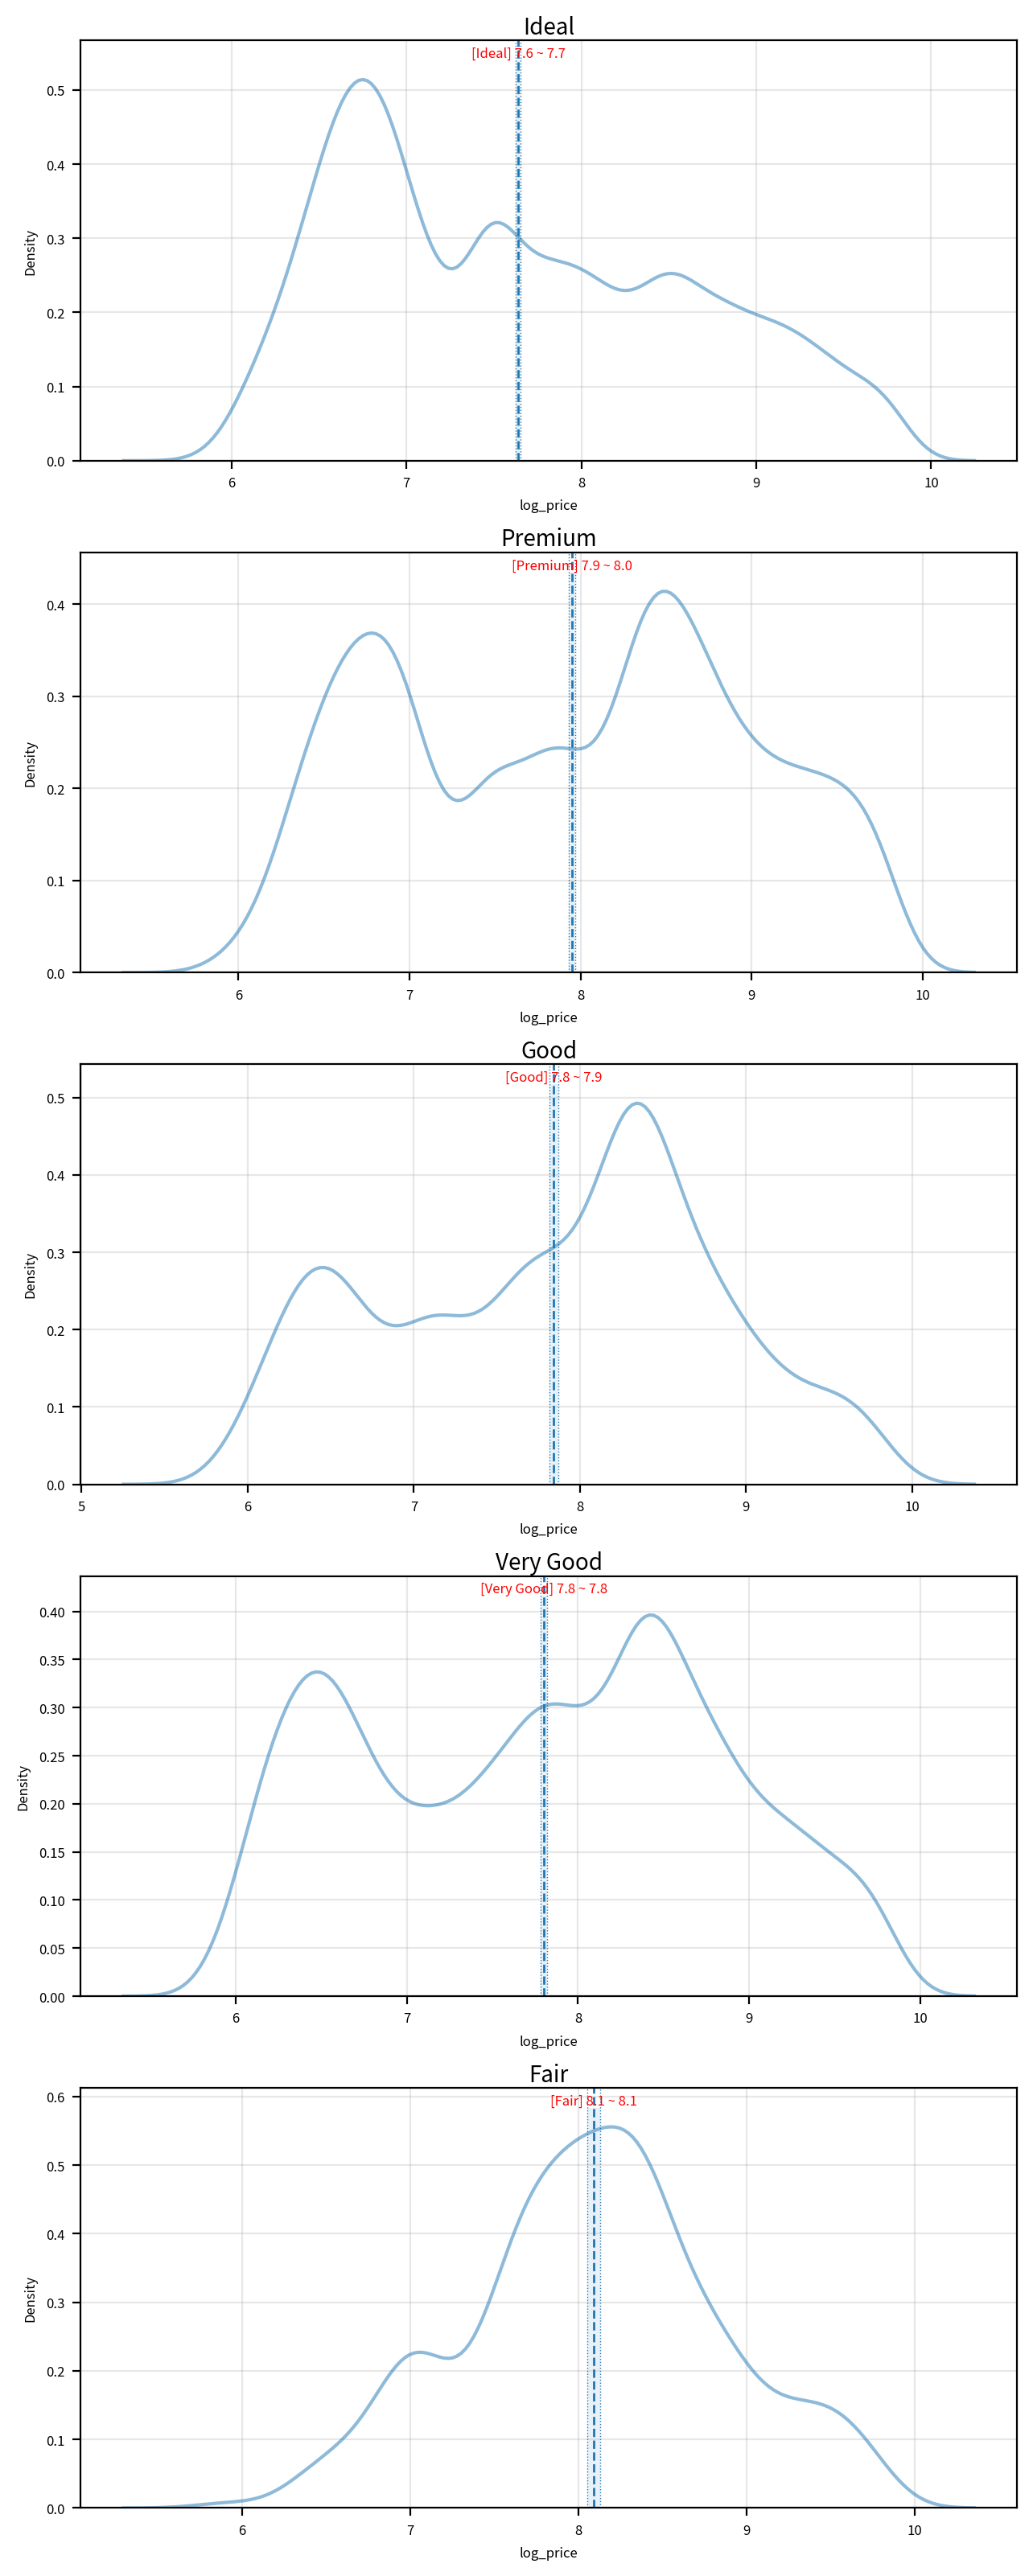

== 이 데이터는 정규성과 등분산성을 모두 만족하지 못한다. ==


,statistic,p-value,result
field,,,
Fair,5.576223,6.153730e-02,True
Good,709.824985,7.302353e-155,False
Ideal,4633.074059,0.000000e+00,False
Premium,9963.829180,0.000000e+00,False
Very Good,4707.964368,0.000000e+00,False
Levene,122.554384,2.623496e-104,False


,Source,ddof1,ddof2,F,p-unc,np2
0,cut,4,9549.181777,273.822085,3.408853e-223,0.018073


statistic: 273.822, p-value: 0.000, 대립가설 채택

=== Games-Howell ===


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,Fair,Good,8.093026,7.842348,0.250678,0.023695,10.579464,3475.310280,0.000000e+00,0.268669
1,Fair,Ideal,8.093026,7.639297,0.453729,0.020264,22.390740,2033.547114,0.000000e+00,0.463783
2,Fair,Premium,8.093026,7.949890,0.143137,0.021022,6.809032,2345.632351,1.250368e-10,0.142343
3,Fair,Very Good,8.093026,7.798620,0.294407,0.021308,13.816722,2469.369582,1.274536e-12,0.291664
4,Good,Ideal,7.842348,7.639297,0.203051,0.015563,13.047181,7355.079311,2.038592e-12,0.205035
5,Good,Premium,7.842348,7.949890,-0.107541,0.016537,-6.503075,9001.024951,8.382498e-10,-0.105702
6,Good,Very Good,7.842348,7.798620,0.043729,0.016900,2.587549,9555.570448,7.270554e-02,0.042803
7,Ideal,Premium,7.639297,7.949890,-0.310593,0.011075,-28.043247,28558.035056,5.575540e-13,-0.308395
8,Ideal,Very Good,7.639297,7.798620,-0.159323,0.011610,-13.722965,24094.432976,0.000000e+00,-0.157939
9,Premium,Very Good,7.949890,7.798620,0.151270,0.012886,11.738671,25366.761821,0.000000e+00,0.146379


Fair와(과) Good은(는) pval 값이 0.05보다 작으므로 유의미한 차이가 존재한다.
Fair와(과) Ideal은(는) pval 값이 0.05보다 작으므로 유의미한 차이가 존재한다.
Fair와(과) Premium은(는) pval 값이 0.05보다 작으므로 유의미한 차이가 존재한다.
Fair와(과) Very Good은(는) pval 값이 0.05보다 작으므로 유의미한 차이가 존재한다.
Good와(과) Ideal은(는) pval 값이 0.05보다 작으므로 유의미한 차이가 존재한다.
Good와(과) Premium은(는) pval 값이 0.05보다 작으므로 유의미한 차이가 존재한다.
Good와(과) Very Good은(는) pval 값이 0.05보다 크므로 유의미한 차이가 존재하지 않는다.
Ideal와(과) Premium은(는) pval 값이 0.05보다 작으므로 유의미한 차이가 존재한다.
Ideal와(과) Very Good은(는) pval 값이 0.05보다 작으므로 유의미한 차이가 존재한다.
Premium와(과) Very Good은(는) pval 값이 0.05보다 작으므로 유의미한 차이가 존재한다.


In [13]:
# 확인할 데이터
field='log_price'
hue_field='cut'
hue_values=df1[hue_field].unique()
hue_count=len(hue_values)

width_px=1280
height_px=640*hue_count
rows=hue_count
cols=1
figsize=(width_px/my_dpi, height_px/my_dpi)
fig, ax=plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

for i, v in enumerate(hue_values):
    temp=df1[df1[hue_field]==v]
    
    sb.kdeplot(data=temp, x=field, fill=False, alpha=0.5, ax=ax[i])
    ax[i].grid(True, alpha=0.3)
    ax[i].set_title(v, fontsize=10, pad=3)

    # 신뢰구간
    max=temp[field].max()
    clevel=0.95
    dof=len(temp[field])-1
    sp_mean=temp[field].mean()
    sp_std=temp[field].std(ddof=1)
    sp_std_error=sp_std/sqrt(len(temp[field]))
    cmin, cmax = t.interval(clevel, dof, loc=sp_mean, scale=sp_std_error)

    ax[i].axvline(cmin, linestyle=':', linewidth=0.5)
    ax[i].axvline(cmax, linestyle=':', linewidth=0.5)
    
    # 평균 표시
    ymin, ymax=ax[i].get_ylim()
    ax[i].fill_between([cmin, cmax], 0, ymax, alpha=0.1)
    ax[i].axvline(sp_mean, linestyle='--', linewidth=1)

    # 텍스트 그리기
    ax[i].text(x=(cmax-cmin)/2+cmin,
            y=ymax,
            s='[%s] %0.1f ~ %0.1f'%(v, cmin, cmax),
            horizontalalignment='center',
            verticalalignment='bottom',
            fontdict={'size':6, 'color':'red'})

plt.tight_layout()
# plt.savefig('myplot.png',dpi=my_dpi)
plt.show()
plt.close()

groups=[(name, grp[field]) for name, grp in df1.groupby(hue_field)]

equal_var_fields=[]
normal_dist=True
report=[]

for name, series in groups:
    s, p=normaltest(series)

    normalize=(p>0.05)
    report.append({
        'field':name,
        'statistic':s,
        'p-value':p,
        'result':normalize
    })
    normal_dist=normal_dist and normalize

if normal_dist:
    n='Bartlett'
    s, p=bartlett(*[s.values for _, s in groups])
    homos=(p>0.05)
    if homos:
        print('== 이 데이터는 정규성과 등분산성을 모두 만족한다. ==')
    else:
        print('== 이 데이터는 정규성은 만족하지만, 등분산성을 만족하지 못한다 ==')
else:
    n='Levene'
    s, p=levene(*[s.values for _, s in groups], center='median')
    homos=(p>0.05)
    if homos:
        print('== 이 데이터는 정규성은 만족하지 못하지만, 등분산성은 만족한다. ==')
    else:
        print('== 이 데이터는 정규성과 등분산성을 모두 만족하지 못한다. ==')

equal_var=p>0.05
report.append({
    'field':n,
    'statistic':s,
    'p-value':p,
    'result':equal_var
})

report_df=DataFrame(report).set_index('field')
display(report_df)

anova_df=df1[[field, hue_field]].copy()

if equal_var:
    pg_anova=anova(data=anova_df, dv=field, between=hue_field)
else:
    pg_anova=welch_anova(data=anova_df, dv=field, between=hue_field)

f_val=pg_anova['F'].iloc[0]
p_val=pg_anova['p-unc'].iloc[0]
if equal_var:
    pg_anova=anova(data=anova_df, dv=field, between=hue_field)
else:
    pg_anova=welch_anova(data=anova_df, dv=field, between=hue_field)
display(pg_anova)
print('statistic: {0:.3f}, p-value: {1:.3f}, {2}가설 채택'.format(f_val, p_val, '대립' if p_val<=0.05 else '귀무'))

if equal_var:
    print('\n=== Tukey HSD ===')
    hoc_df=pairwise_tukey(data=anova_df, dv=field, between=hue_field)
    display(hoc_df)
    for i in range(0, len(hoc_df)):
        if hoc_df['pval'][i]<0.05:
            print('%s와(과) %s은(는) p-tukey 값이 0.05보다 작으므로 유의미한 차이가 존재한다.'%(hoc_df['A'][i], hoc_df['B'][i]))
        else:
            print('%s와(과) %s은(는) p-tukey 값이 0.05보다 크므로 유의미한 차이가 존재하지 않는다.'%(hoc_df['A'][i], hoc_df['B'][i]))
else:
    print('\n=== Games-Howell ===')
    hoc_df=pairwise_gameshowell(data=anova_df, dv=field, between=hue_field)
    display(hoc_df)
    for i in range(0, len(hoc_df)):
        if hoc_df['pval'][i]<0.05:
            print('%s와(과) %s은(는) pval 값이 0.05보다 작으므로 유의미한 차이가 존재한다.'%(hoc_df['A'][i], hoc_df['B'][i]))
        else:
            print('%s와(과) %s은(는) pval 값이 0.05보다 크므로 유의미한 차이가 존재하지 않는다.'%(hoc_df['A'][i], hoc_df['B'][i]))

Cut 변수는 정규성을 만족하지 못하기 때문에, Levene 검정을 통해 cut이라는 변수가 정말 log_price에 영향을 주는 지 검정을 실시하였다.  
이 때 p-value<0.05 이므로, 95% 신뢰구간 안에서 대립가설을 채택하여 cut 변수가 log_price에 영향을 준다는 것을 알 수 있다.  

여기서 cut 변수가 등분산성을 만족하지 못하므로, cut 변수의 등급들을 Games-Howell을 통해 일원분산분석을 진행하였다.  
이 때에 Ideal 등급과 Premium 등급은 p-value<0.05 이므로, 유의미한 차이가 존재하고, Ideal 등급의 log_price가 더 높음을 알 수 있다.  

이를 이용해 간단히 등급별로 log_price의 순위를 매겨보면 아래와 같다.

> Fair < Premium < Good <= Very Good < Ideal

(Good과 Very Good에는 유의미한 차이가 존재하지 않음)

## 🎯미션7. 품질 요인들에 대한 가격의 이원분산분석

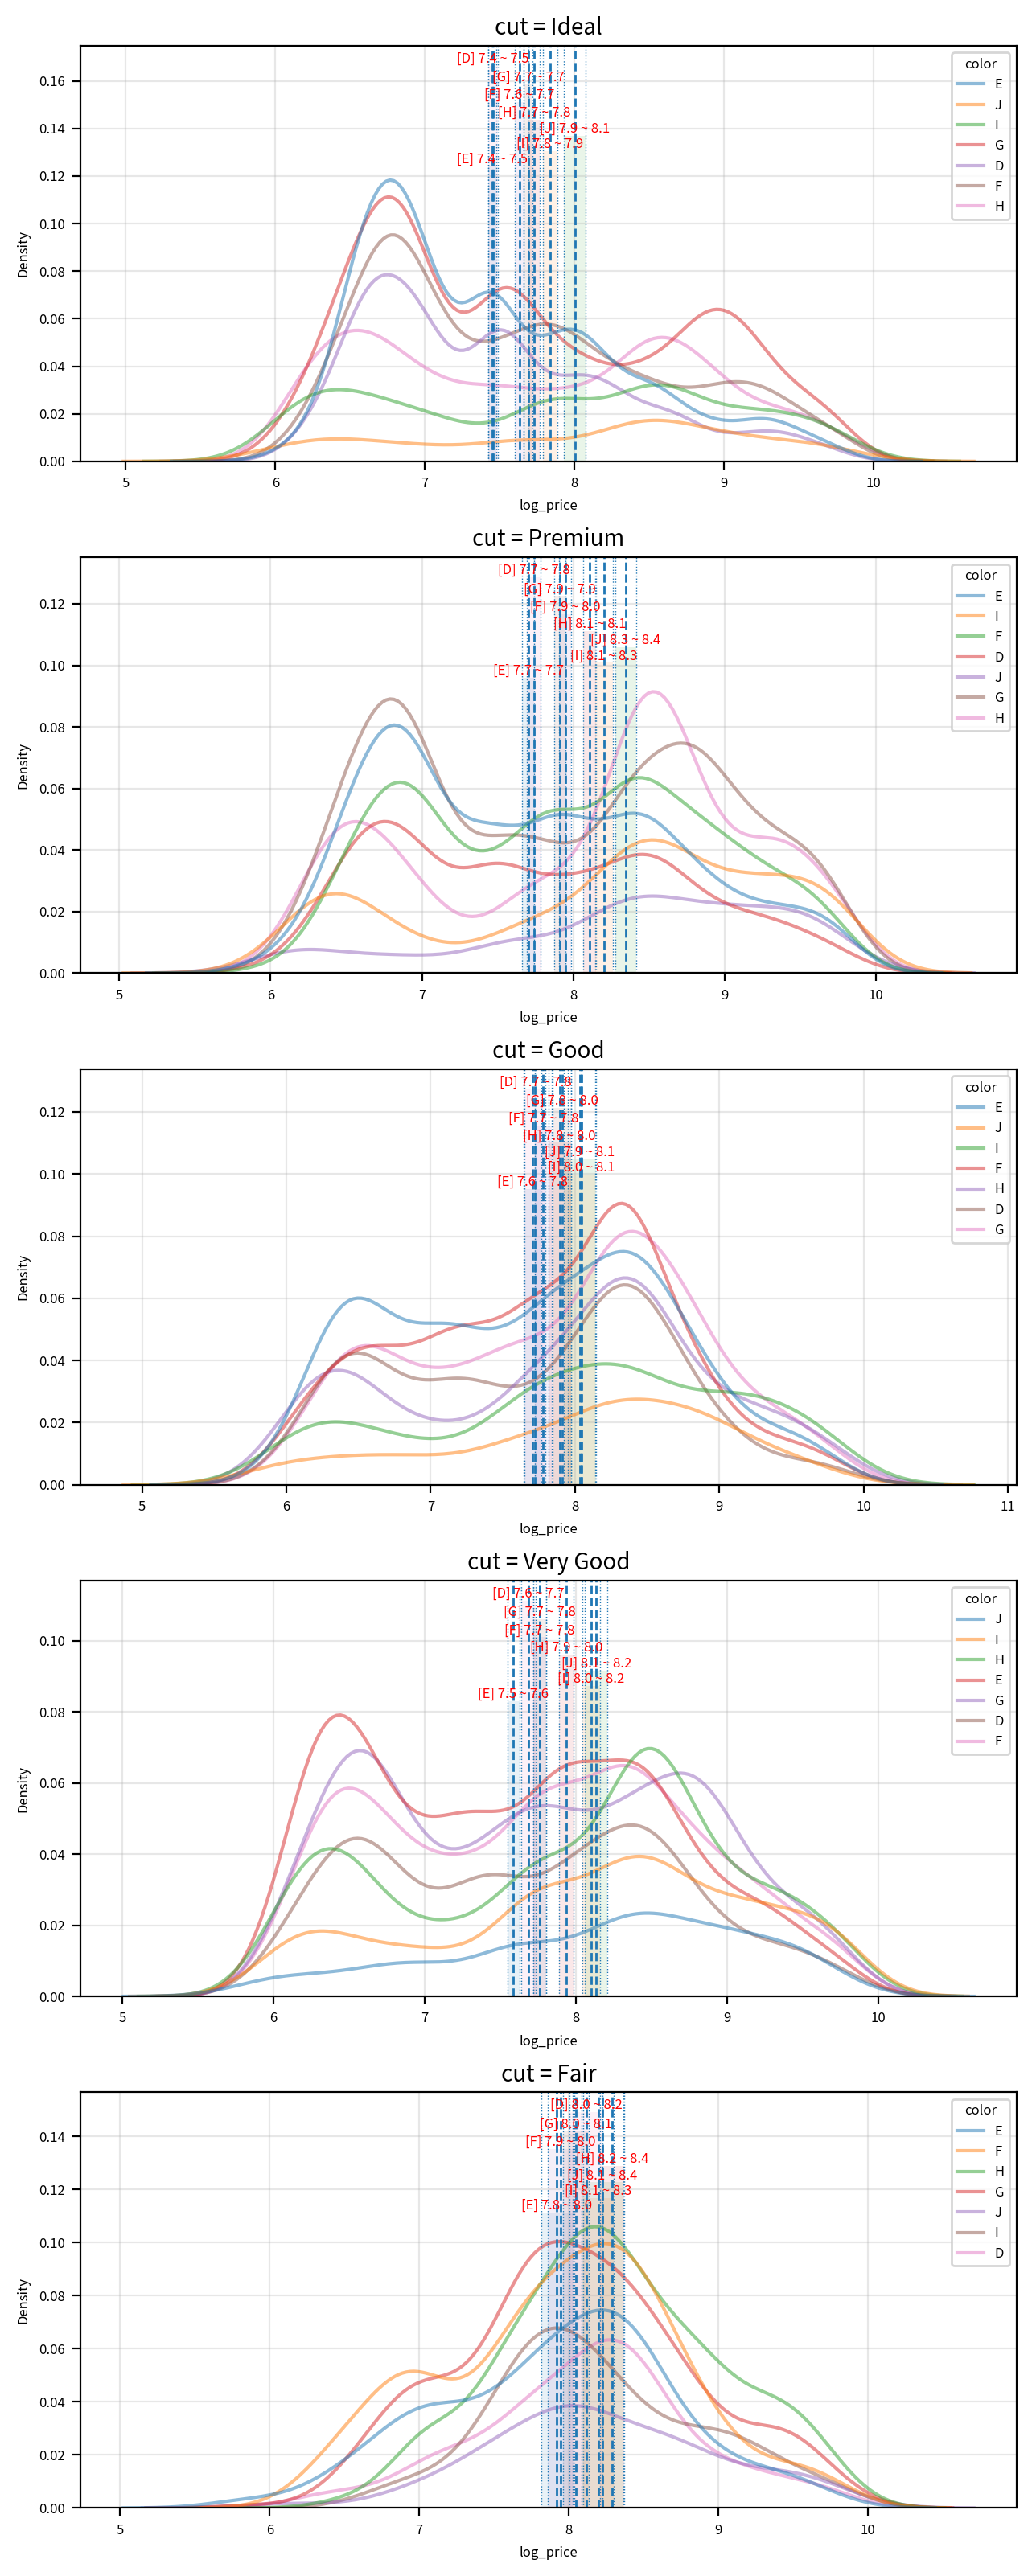

== 이 데이터는 정규성과 등분산성을 모두 만족하지 못한다. ==


,statistic,p-value,result
field,,,
"Ideal, E",310.474146,3.814133e-68,False
"Ideal, I",2720.495708,0.000000e+00,False
"Ideal, J",258.512577,7.323307e-57,False
"Ideal, H",4463.144354,0.000000e+00,False
"Ideal, F",526.215760,5.416261e-115,False
"Ideal, G",2433.024869,0.000000e+00,False
"Ideal, D",213.568495,4.209113e-47,False
"Premium, E",358.024223,1.803133e-78,False
"Premium, I",305.335780,4.979410e-67,False


,Source,SS,DF,MS,F,p-unc,np2
0,cut,898.322327,4.0,224.580582,227.999498,1.871102e-194,0.016644
1,color,1323.798925,6.0,220.633154,223.991977,1.197633e-283,0.024336
2,cut * color,94.892136,24.0,3.953839,4.014031,1.289828e-10,0.001785
3,Residual,53074.024237,53882.0,0.985005,NaN,NaN,NaN


-> cut 효과는 유의함. (대립가설 채택 : p <= 0.05)
-> color 효과는 유의함. (대립가설 채택 : p <= 0.05)
-> cut * color 효과는 유의함. (대립가설 채택 : p <= 0.05)
-> Residual 효과는 유의하지 않음. (귀무가설 채택 : p > 0.05)

[cut]
- 주효과 유의함 (p=1.87e-194) -> 사후검정 수행

=== Games-Howell ===


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,Fair,Good,8.093026,7.842348,0.250678,0.023695,10.579464,3475.310280,0.000000e+00,0.268669
1,Fair,Ideal,8.093026,7.639297,0.453729,0.020264,22.390740,2033.547114,0.000000e+00,0.463783
2,Fair,Premium,8.093026,7.949890,0.143137,0.021022,6.809032,2345.632351,1.250368e-10,0.142343
3,Fair,Very Good,8.093026,7.798620,0.294407,0.021308,13.816722,2469.369582,1.274536e-12,0.291664
4,Good,Ideal,7.842348,7.639297,0.203051,0.015563,13.047181,7355.079311,2.038592e-12,0.205035
5,Good,Premium,7.842348,7.949890,-0.107541,0.016537,-6.503075,9001.024951,8.382498e-10,-0.105702
6,Good,Very Good,7.842348,7.798620,0.043729,0.016900,2.587549,9555.570448,7.270554e-02,0.042803
7,Ideal,Premium,7.639297,7.949890,-0.310593,0.011075,-28.043247,28558.035056,5.575540e-13,-0.308395
8,Ideal,Very Good,7.639297,7.798620,-0.159323,0.011610,-13.722965,24094.432976,0.000000e+00,-0.157939
9,Premium,Very Good,7.949890,7.798620,0.151270,0.012886,11.738671,25366.761821,0.000000e+00,0.146379



[color]
- 주효과 유의함 (p=1.2e-283) -> 사후검정 수행

=== Games-Howell ===


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,D,E,7.616603,7.579398,0.037205,0.014631,2.542939,14557.712955,1.441898e-01,0.040187
1,D,F,7.616603,7.762331,-0.145727,0.014993,-9.719835,14960.777520,0.000000e+00,-0.153289
2,D,G,7.616603,7.788974,-0.172371,0.014839,-11.615888,15427.251815,1.980993e-11,-0.173966
3,D,H,7.616603,7.917313,-0.300710,0.016209,-18.551575,15005.323997,9.056977e-12,-0.299600
4,D,I,7.616603,8.022663,-0.406060,0.018766,-21.638619,10552.203050,0.000000e+00,-0.402056
5,D,J,7.616603,8.145970,-0.529367,0.022593,-23.430733,4750.050236,3.972489e-12,-0.551216
6,E,F,7.579398,7.762331,-0.182933,0.013624,-13.426809,19233.835576,1.107869e-11,-0.193255
7,E,G,7.579398,7.788974,-0.209576,0.013455,-15.575758,21048.493356,3.768097e-12,-0.213513
8,E,H,7.579398,7.917313,-0.337915,0.014953,-22.598791,16581.751748,3.876344e-12,-0.341028
9,E,I,7.579398,8.022663,-0.443265,0.017691,-25.055385,9636.279947,0.000000e+00,-0.446157



[cut * color] 상호작용 효과
- 상호작용 유의함 (p=1.29e-10) -> 단순주효과 분석 필요


In [14]:
# 확인할 데이터
field='log_price'
group_field='cut'
hue_field='color'

# 데이터 정리
df2=df1[[field, group_field, hue_field]]
group_values=df2[group_field].unique()
group_count=len(group_values)
hue_values=df2[hue_field].unique()

# 그래프 초기화
rows=group_count
cols=1
width_px=1280*cols
height_px=640*rows
figsize=(width_px/my_dpi, height_px/my_dpi)
fig, ax=plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 그래프 그리기
for i, v in enumerate(group_values):
    temp=df2[df2[group_field]==v]
    
    sb.kdeplot(data=temp, x=field, hue=hue_field, fill=False, alpha=0.5, ax=ax[i])
    ax[i].grid(True, alpha=0.3)
    ax[i].set_title('{0} = {1}'.format(group_field, v), fontsize=10, pad=5)

    for h in hue_values:
        temp_sub=temp[temp[hue_field]==h]

        max=temp_sub[field].max()
        clevel=0.95
        dof=len(temp_sub[field])-1
        sp_mean=temp_sub[field].mean()
        sp_std=temp_sub[field].std(ddof=1)
        sp_std_error=sp_std/sqrt(len(temp_sub[field]))
        cmin, cmax = t.interval(clevel, dof, loc=sp_mean, scale=sp_std_error)

        ax[i].axvline(cmin, linestyle=':', linewidth=0.5)
        ax[i].axvline(cmax, linestyle=':', linewidth=0.5)
        
        # 평균 표시
        ymin, ymax=ax[i].get_ylim()
        ax[i].fill_between([cmin, cmax], 0, ymax, alpha=0.1)
        ax[i].axvline(sp_mean, linestyle='--', linewidth=1)

        # 텍스트 그리기
        ax[i].text(x=(cmax-cmin)/2+cmin,
                y=ymax,
                s='[%s] %0.1f ~ %0.1f'%(h, cmin, cmax),
                horizontalalignment='center',
                verticalalignment='bottom',
                fontdict={'size':6, 'color':'red'})

plt.tight_layout()
# plt.savefig('myplot.png',dpi=my_dpi)
plt.show()
plt.close()

# 분산 분석의 가정 확인
groups=[(name, grp[field]) for name, grp in df2.groupby(hue_field)]

equal_var_fields=[]
normal_dist=True
report=[]

for i in group_values:
    for j in hue_values:
        filtered_data=df2[(df2[group_field]==i)&(df2[hue_field]==j)][field]
        equal_var_fields.append(filtered_data)

        s, p=normaltest(filtered_data)
        normalize=(p>0.05)
        report.append({
            'field':'{0}, {1}'.format(i,j),
            'statistic':s,
            'p-value':p,
            'result':normalize
        })
        normal_dist=normal_dist and normalize

if normal_dist:
    n='Bartlett'
    s, p=bartlett(*equal_var_fields)
    homos=(p>0.05)
    if homos:
        print('== 이 데이터는 정규성과 등분산성을 모두 만족한다. ==')
    else:
        print('== 이 데이터는 정규성은 만족하지만, 등분산성을 만족하지 못한다 ==')
else:
    n='Levene'
    s, p=levene(*equal_var_fields, center='median')
    homos=(p>0.05)
    if homos:
        print('== 이 데이터는 정규성은 만족하지 못하지만, 등분산성은 만족한다. ==')
    else:
        print('== 이 데이터는 정규성과 등분산성을 모두 만족하지 못한다. ==')

equal_var=p>0.05
report.append({
    'field':n,
    'statistic':s,
    'p-value':p,
    'result':equal_var
})

report_df=DataFrame(report).set_index('field')
display(report_df)

# # 이원 분산 분석
# if equal_var:
pg_anova=anova(data=df2, dv=field, between=[group_field, hue_field])
# else:
#     pg_anova=welch_anova(data=df2, dv=field, between=[group_field, hue_field])
display(pg_anova)

for idx in pg_anova.index:
    row=pg_anova.iloc[idx]
    source=row['Source']
    p_val=row['p-unc']

    if p_val<=0.05:
        print(f'-> {source} 효과는 유의함. (대립가설 채택 : p <= 0.05)')
    else:
        print(f'-> {source} 효과는 유의하지 않음. (귀무가설 채택 : p > 0.05)')

# 사후 검정
xname=[group_field, hue_field]
levels={}

for factor in xname:
    level_count=df2[factor].nunique()
    levels[factor]=level_count

pvals={}

for index, row in pg_anova.iterrows():
    source_name=row['Source']
    p_value=row['p-unc']
    pvals[source_name]=p_value
for factor in xname:
    print(f'\n[{factor}]')
    if levels[factor]<=2:
        print(f'- {levels[factor]}수준 요인이므로 사후검정이 필요 없습니다.')
        continue
    p_val=pvals.get(factor, None)
    if p_val is None:
        print('- ANOVA 결과에서 해당 요인을 찾을 수 없습니다.')
        continue
    if p_val > 0.05:
        print(f'- 주효과 유의하지 않음 (p={p_val:.3g}) -> 사후검정 수행 안함')
        continue
    print(f'- 주효과 유의함 (p={p_val:.3g}) -> 사후검정 수행')

    if equal_var:
        print('\n=== Tukey HSD ===')
        hoc_df=pairwise_tukey(data=df2, dv=field, between=factor)
    else:
        print('\n=== Games-Howell ===')
        hoc_df=pairwise_gameshowell(data=df2, dv=field, between=factor)
    display(hoc_df)

# 상호작용 자동 처리
interaction_names=[src for src in pvals.keys() if '*' in src]

for inter in interaction_names:
    p_val=pvals[inter]
    print(f'\n[{inter}] 상호작용 효과')

    if p_val<=0.05:
        print(f'- 상호작용 유의함 (p={p_val:.3g}) -> 단순주효과 분석 필요')
    else:
        print(f'- 상호작용 유의하지 않음 (p={p_val:.3g}) -> 단순주효과 분석 필요 없음')

cut과 color 모두 p-value가 0.05보다 작기 때문에 log_price에 대해서 유의미한 변수임을 알 수 있다.  
또한 cut과 color가 같이 작용하였을 때에도 p-value가 0.05보다 작기에 log_price에 대해서 유의미한 변수임을 알 수 있다.  

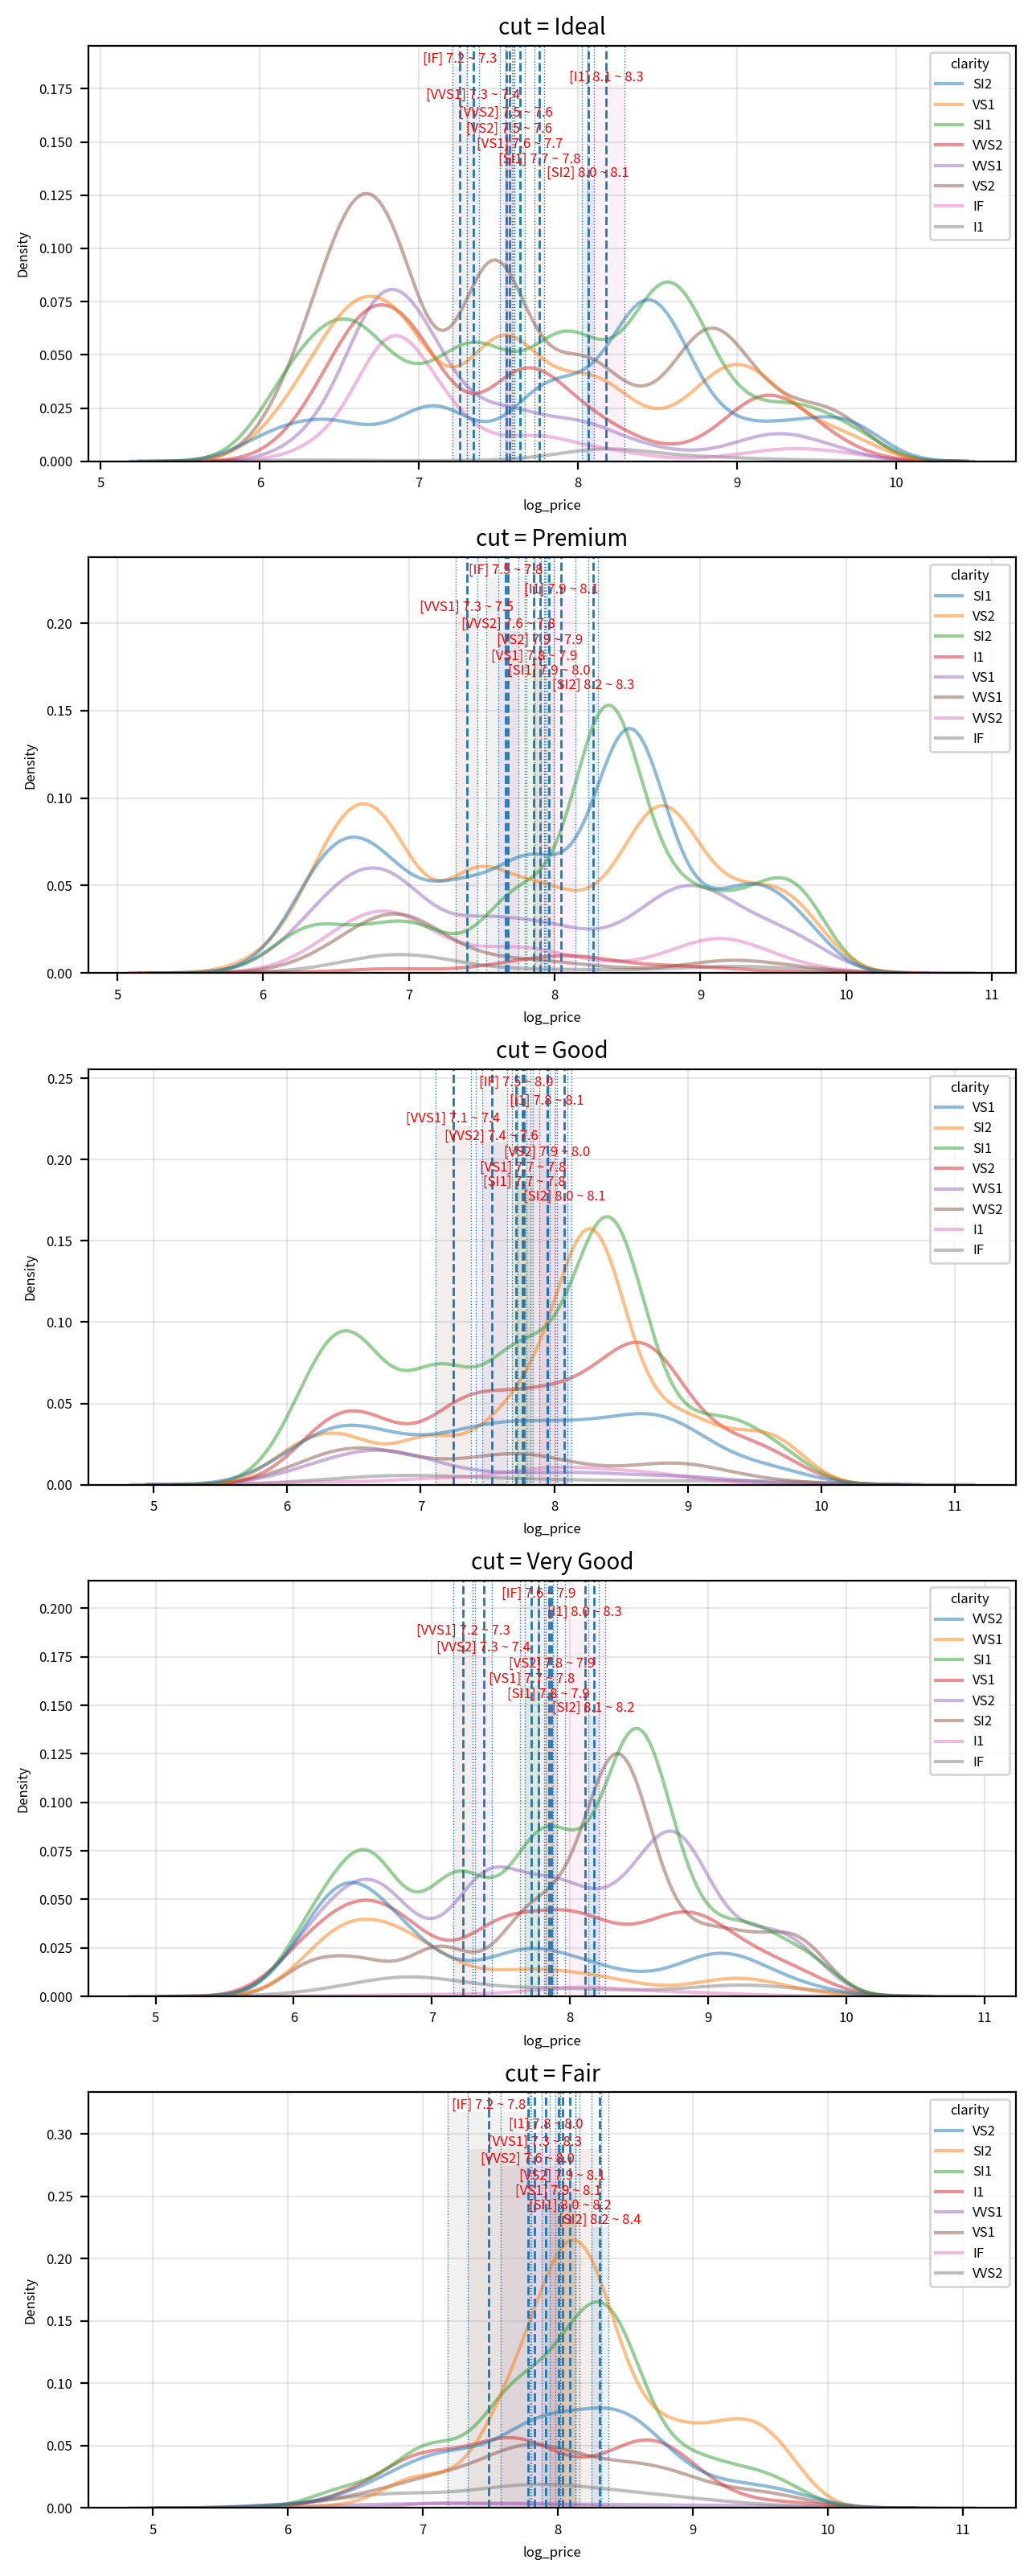

== 이 데이터는 정규성과 등분산성을 모두 만족하지 못한다. ==


,statistic,p-value,result
field,,,
"Ideal, SI2",101.815825,7.779910e-23,False
"Ideal, SI1",1354.485853,7.535883e-295,False
"Ideal, VS1",1045.424224,9.750213e-228,False
"Ideal, VS2",933.694117,1.781963e-203,False
"Ideal, VVS2",342.460550,4.321520e-75,False
"Ideal, VVS1",361.453672,3.245880e-79,False
"Ideal, I1",34.352965,3.470151e-08,False
"Ideal, IF",366.283289,2.901312e-80,False
"Premium, SI2",121.984421,3.246531e-27,False


,Source,SS,DF,MS,F,p-unc,np2
0,cut,465.356278,4.0,116.339069,120.775301,8.797913e-103,0.008887
1,clarity,2295.329192,7.0,327.904170,340.407783,0.000000e+00,0.042354
2,cut * clarity,299.357176,28.0,10.691328,11.099008,2.578044e-49,0.005735
3,Residual,51898.028929,53877.0,0.963269,NaN,NaN,NaN


-> cut 효과는 유의함. (대립가설 채택 : p <= 0.05)
-> clarity 효과는 유의함. (대립가설 채택 : p <= 0.05)
-> cut * clarity 효과는 유의함. (대립가설 채택 : p <= 0.05)
-> Residual 효과는 유의하지 않음. (귀무가설 채택 : p > 0.05)

[cut]
- 주효과 유의함 (p=8.8e-103) -> 사후검정 수행

=== Games-Howell ===


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,Fair,Good,8.093026,7.842348,0.250678,0.023695,10.579464,3475.310280,0.000000e+00,0.268669
1,Fair,Ideal,8.093026,7.639297,0.453729,0.020264,22.390740,2033.547114,0.000000e+00,0.463783
2,Fair,Premium,8.093026,7.949890,0.143137,0.021022,6.809032,2345.632351,1.250368e-10,0.142343
3,Fair,Very Good,8.093026,7.798620,0.294407,0.021308,13.816722,2469.369582,1.274536e-12,0.291664
4,Good,Ideal,7.842348,7.639297,0.203051,0.015563,13.047181,7355.079311,2.038592e-12,0.205035
5,Good,Premium,7.842348,7.949890,-0.107541,0.016537,-6.503075,9001.024951,8.382498e-10,-0.105702
6,Good,Very Good,7.842348,7.798620,0.043729,0.016900,2.587549,9555.570448,7.270554e-02,0.042803
7,Ideal,Premium,7.639297,7.949890,-0.310593,0.011075,-28.043247,28558.035056,5.575540e-13,-0.308395
8,Ideal,Very Good,7.639297,7.798620,-0.159323,0.011610,-13.722965,24094.432976,0.000000e+00,-0.157939
9,Premium,Very Good,7.949890,7.798620,0.151270,0.012886,11.738671,25366.761821,0.000000e+00,0.146379



[clarity]
- 주효과 유의함 (p=0) -> 사후검정 수행

=== Games-Howell ===


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,I1,IF,8.027355,7.405190,0.622165,0.034921,17.816108,1685.065183,6.582512e-13,0.713736
1,I1,SI1,8.027355,7.847698,0.179657,0.028676,6.265097,891.560216,1.618613e-08,0.183797
2,I1,SI2,8.027355,8.166240,-0.138885,0.028966,-4.794721,927.620049,5.170983e-05,-0.153377
3,I1,VS1,8.027355,7.724674,0.302681,0.029688,10.195387,1021.872928,0.000000e+00,0.295473
4,I1,VS2,8.027355,7.762590,0.264765,0.028888,9.165196,918.010526,0.000000e+00,0.259862
5,I1,VVS1,8.027355,7.322330,0.705025,0.031076,22.687377,1209.480262,7.900347e-13,0.810581
6,I1,VVS2,8.027355,7.530843,0.496512,0.030897,16.070059,1188.903307,2.120526e-14,0.499883
7,IF,SI1,7.405190,7.847698,-0.442507,0.023387,-18.920961,2393.287329,7.130962e-13,-0.451114
8,IF,SI2,7.405190,8.166240,-0.761049,0.023742,-32.054747,2532.140054,0.000000e+00,-0.829351
9,IF,VS1,7.405190,7.724674,-0.319483,0.024618,-12.977804,2897.185488,0.000000e+00,-0.311857



[cut * clarity] 상호작용 효과
- 상호작용 유의함 (p=2.58e-49) -> 단순주효과 분석 필요


In [15]:
# 확인할 데이터
field='log_price'
group_field='cut'
hue_field='clarity'

# 데이터 정리
df2=df1[[field, group_field, hue_field]]
group_values=df2[group_field].unique()
group_count=len(group_values)
hue_values=df2[hue_field].unique()

# 그래프 초기화
rows=group_count
cols=1
width_px=1280*cols
height_px=640*rows
figsize=(width_px/my_dpi, height_px/my_dpi)
fig, ax=plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 그래프 그리기
for i, v in enumerate(group_values):
    temp=df2[df2[group_field]==v]
    
    sb.kdeplot(data=temp, x=field, hue=hue_field, fill=False, alpha=0.5, ax=ax[i])
    ax[i].grid(True, alpha=0.3)
    ax[i].set_title('{0} = {1}'.format(group_field, v), fontsize=10, pad=5)

    for h in hue_values:
        temp_sub=temp[temp[hue_field]==h]

        max=temp_sub[field].max()
        clevel=0.95
        dof=len(temp_sub[field])-1
        sp_mean=temp_sub[field].mean()
        sp_std=temp_sub[field].std(ddof=1)
        sp_std_error=sp_std/sqrt(len(temp_sub[field]))
        cmin, cmax = t.interval(clevel, dof, loc=sp_mean, scale=sp_std_error)

        ax[i].axvline(cmin, linestyle=':', linewidth=0.5)
        ax[i].axvline(cmax, linestyle=':', linewidth=0.5)
        
        # 평균 표시
        ymin, ymax=ax[i].get_ylim()
        ax[i].fill_between([cmin, cmax], 0, ymax, alpha=0.1)
        ax[i].axvline(sp_mean, linestyle='--', linewidth=1)

        # 텍스트 그리기
        ax[i].text(x=(cmax-cmin)/2+cmin,
                y=ymax,
                s='[%s] %0.1f ~ %0.1f'%(h, cmin, cmax),
                horizontalalignment='center',
                verticalalignment='bottom',
                fontdict={'size':6, 'color':'red'})

plt.tight_layout()
# plt.savefig('myplot.png',dpi=my_dpi)
plt.show()
plt.close()

# 분산 분석의 가정 확인
groups=[(name, grp[field]) for name, grp in df2.groupby(hue_field)]

equal_var_fields=[]
normal_dist=True
report=[]

for i in group_values:
    for j in hue_values:
        filtered_data=df2[(df2[group_field]==i)&(df2[hue_field]==j)][field]
        equal_var_fields.append(filtered_data)

        s, p=normaltest(filtered_data)
        normalize=(p>0.05)
        report.append({
            'field':'{0}, {1}'.format(i,j),
            'statistic':s,
            'p-value':p,
            'result':normalize
        })
        normal_dist=normal_dist and normalize

if normal_dist:
    n='Bartlett'
    s, p=bartlett(*equal_var_fields)
    homos=(p>0.05)
    if homos:
        print('== 이 데이터는 정규성과 등분산성을 모두 만족한다. ==')
    else:
        print('== 이 데이터는 정규성은 만족하지만, 등분산성을 만족하지 못한다 ==')
else:
    n='Levene'
    s, p=levene(*equal_var_fields, center='median')
    homos=(p>0.05)
    if homos:
        print('== 이 데이터는 정규성은 만족하지 못하지만, 등분산성은 만족한다. ==')
    else:
        print('== 이 데이터는 정규성과 등분산성을 모두 만족하지 못한다. ==')

equal_var=p>0.05
report.append({
    'field':n,
    'statistic':s,
    'p-value':p,
    'result':equal_var
})

report_df=DataFrame(report).set_index('field')
display(report_df)

# # 이원 분산 분석
# if equal_var:
pg_anova=anova(data=df2, dv=field, between=[group_field, hue_field])
# else:
#     pg_anova=welch_anova(data=df2, dv=field, between=[group_field, hue_field])
display(pg_anova)

for idx in pg_anova.index:
    row=pg_anova.iloc[idx]
    source=row['Source']
    p_val=row['p-unc']

    if p_val<=0.05:
        print(f'-> {source} 효과는 유의함. (대립가설 채택 : p <= 0.05)')
    else:
        print(f'-> {source} 효과는 유의하지 않음. (귀무가설 채택 : p > 0.05)')

# 사후 검정
xname=[group_field, hue_field]
levels={}

for factor in xname:
    level_count=df2[factor].nunique()
    levels[factor]=level_count

pvals={}

for index, row in pg_anova.iterrows():
    source_name=row['Source']
    p_value=row['p-unc']
    pvals[source_name]=p_value
for factor in xname:
    print(f'\n[{factor}]')
    if levels[factor]<=2:
        print(f'- {levels[factor]}수준 요인이므로 사후검정이 필요 없습니다.')
        continue
    p_val=pvals.get(factor, None)
    if p_val is None:
        print('- ANOVA 결과에서 해당 요인을 찾을 수 없습니다.')
        continue
    if p_val > 0.05:
        print(f'- 주효과 유의하지 않음 (p={p_val:.3g}) -> 사후검정 수행 안함')
        continue
    print(f'- 주효과 유의함 (p={p_val:.3g}) -> 사후검정 수행')

    if equal_var:
        print('\n=== Tukey HSD ===')
        hoc_df=pairwise_tukey(data=df2, dv=field, between=factor)
    else:
        print('\n=== Games-Howell ===')
        hoc_df=pairwise_gameshowell(data=df2, dv=field, between=factor)
    display(hoc_df)

# 상호작용 자동 처리
interaction_names=[src for src in pvals.keys() if '*' in src]

for inter in interaction_names:
    p_val=pvals[inter]
    print(f'\n[{inter}] 상호작용 효과')

    if p_val<=0.05:
        print(f'- 상호작용 유의함 (p={p_val:.3g}) -> 단순주효과 분석 필요')
    else:
        print(f'- 상호작용 유의하지 않음 (p={p_val:.3g}) -> 단순주효과 분석 필요 없음')

cut과 clarity 모두 p-value가 0.05보다 작기 때문에 log_price에 대해서 유의미한 변수임을 알 수 있다.  
또한 cut과 clarity가 같이 작용하였을 때에도 p-value가 0.05보다 작기에 log_price에 대해서 유의미한 변수임을 알 수 있다.  

## 🎯미션8. 가격과 가장 가까운 물리적 변수 찾기

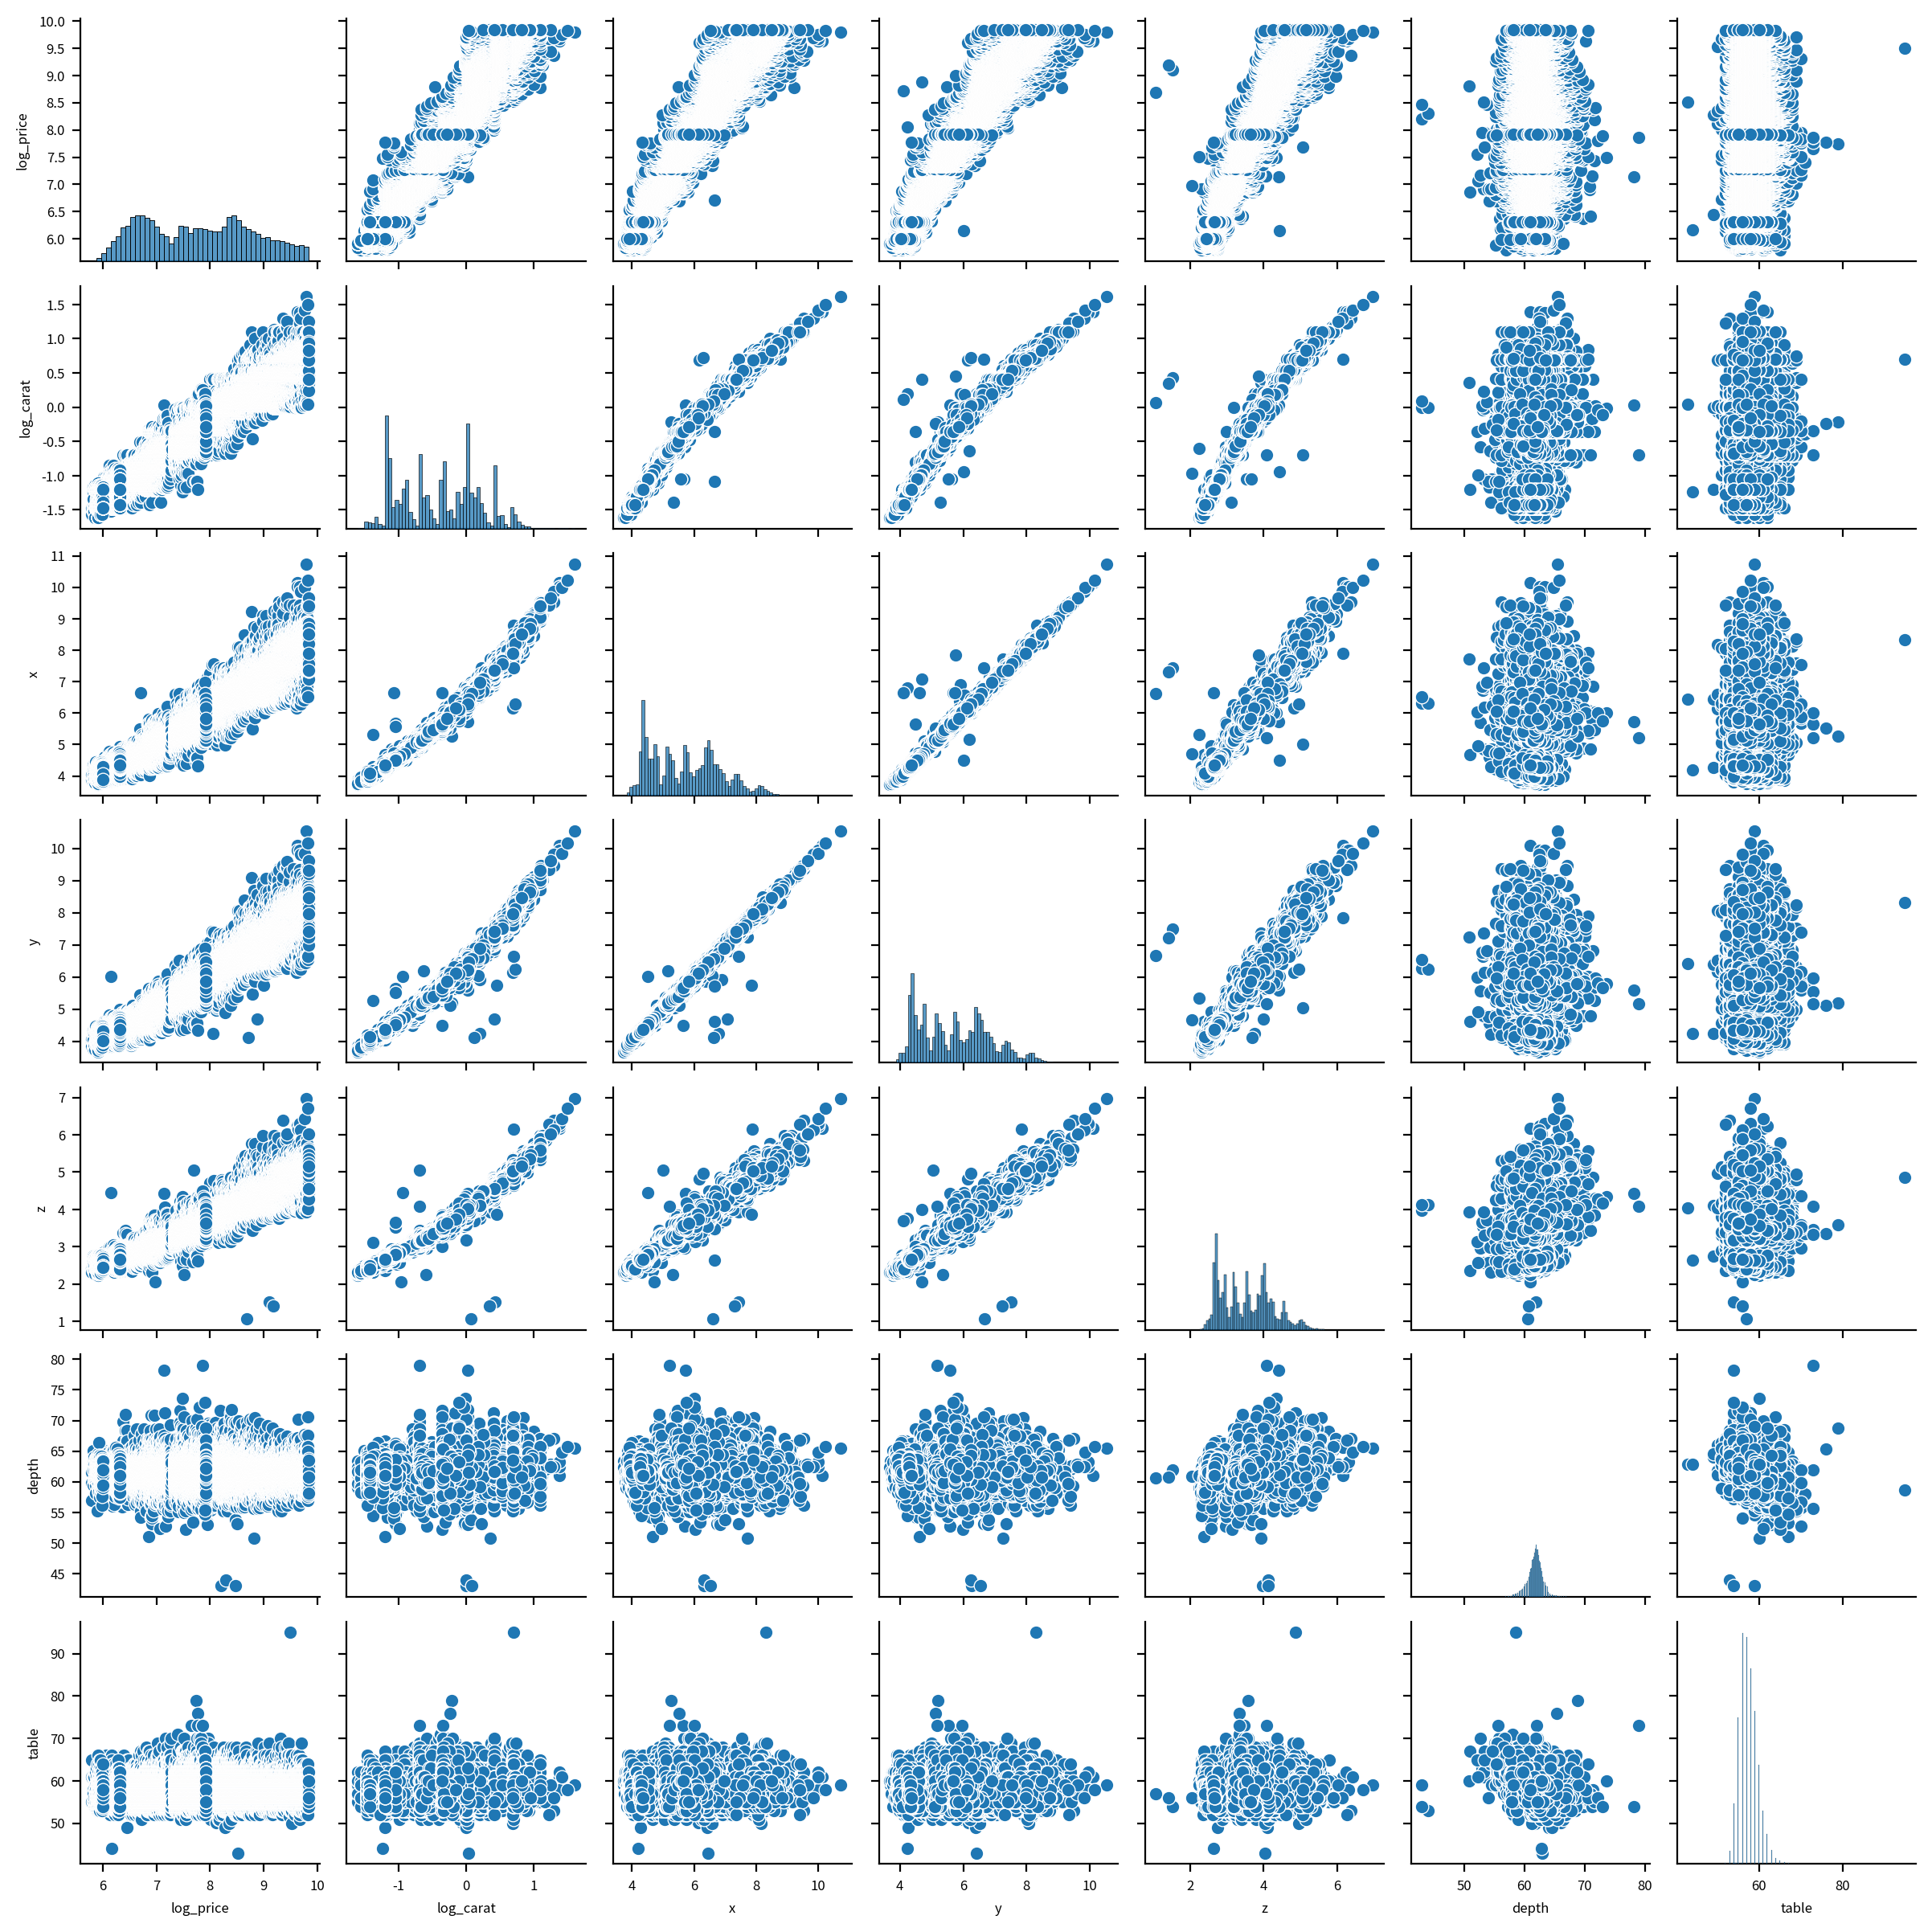

✅ 이상치 요약


,original_skew,log_skew,outliers(|z|>3)
log_price,0.115460,-0.226092,0.0
log_carat,0.096209,-0.144644,6.0
x,0.398282,-0.012994,35.0
y,0.392737,-0.008131,31.0
z,0.393823,0.153999,38.0
depth,-0.081694,-2.177616,685.0
table,0.796757,0.159774,335.0


🎈 상관 분석


,var_a,var_b,linearity,outlier_flag,chosen,corr,pval,significant,strength
0,log_price,log_carat,False,True,spearman,0.962886,0.000000e+00,True,Very Strong
1,log_price,x,False,True,spearman,0.963752,0.000000e+00,True,Very Strong
2,log_price,y,False,True,spearman,0.963244,0.000000e+00,True,Very Strong
3,log_price,z,False,True,spearman,0.958654,0.000000e+00,True,Very Strong
4,log_price,depth,False,True,spearman,0.010058,1.952150e-02,True,Very Weak
5,log_price,table,False,True,spearman,0.171799,0.000000e+00,True,Very Weak
6,log_carat,x,False,True,spearman,0.996644,0.000000e+00,True,Very Strong
7,log_carat,y,False,True,spearman,0.996078,0.000000e+00,True,Very Strong
8,log_carat,z,False,True,spearman,0.994797,0.000000e+00,True,Very Strong
9,log_carat,depth,True,True,spearman,0.030196,2.334186e-12,True,Very Weak


📊 상관 행렬


,depth,log_carat,log_price,table,x,y,z
depth,1.000000,0.030196,0.010058,-0.245120,-0.023167,-0.025135,0.103635
log_carat,0.030196,1.000000,0.962886,0.194933,0.996644,0.996078,0.994797
log_price,0.010058,0.962886,1.000000,0.171799,0.963752,0.963244,0.958654
table,-0.245120,0.194933,0.171799,1.000000,0.202286,0.195885,0.160407
x,-0.023167,0.996644,0.963752,0.202286,1.000000,0.998005,0.988466
y,-0.025135,0.996078,0.963244,0.195885,0.998005,1.000000,0.988184
z,0.103635,0.994797,0.958654,0.160407,0.988466,0.988184,1.000000


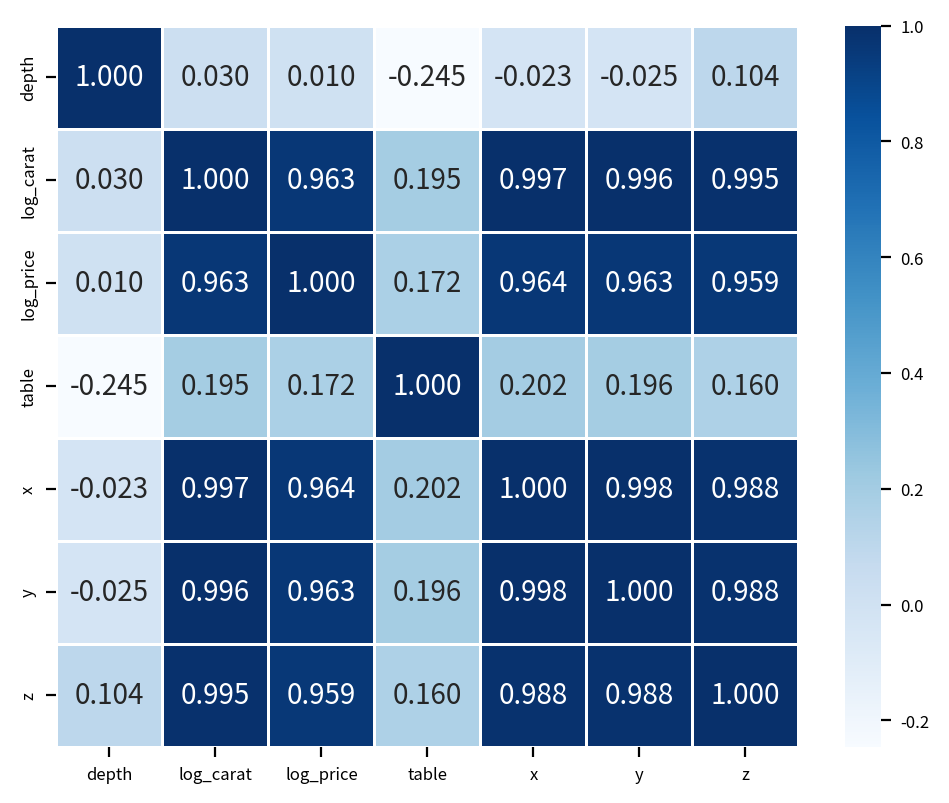

In [16]:
# 데이터 입력
df=df1.filter(['log_price','log_carat','x','y','z','depth','table'])

# 패키지 참조
from hossam import load_data
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, pearsonr, spearmanr
from itertools import combinations

# 그래프 초기화
my_dpi=200
font_path='../NotoSansKR-Regular.ttf'
fm.fontManager.addfont(font_path)
font_prop=fm.FontProperties(fname=font_path)
font_name=font_prop.get_name()
plt.rcParams['font.family']=font_name
plt.rcParams['font.size']=6
plt.rcParams['axes.unicode_minus']=False

# 페어플롯으로 형태 확인
width_px=2400
height_px=2400
figsize=(width_px/my_dpi, height_px/my_dpi)

g=sb.pairplot(df, diag_kind='hist')
g.fig.set_size_inches(figsize)
g.fig.set_dpi(my_dpi)
plt.tight_layout()
plt.show()
plt.close()

# 이상치 요약
print('='*50)
print('✅ 이상치 요약')
print('='*50)
skew_outlier={}
for col in df.columns:
    temp=df[col].dropna()
    skew_original=temp.skew()
    z_scores=zscore(temp)
    outlier_count=int(np.sum(np.abs(z_scores)>3))

    data_log=np.log1p(temp-temp.min()+1)
    skew_log=data_log.skew()
    skew_outlier[col]={
        'original_skew':skew_original,
        'log_skew':skew_log,
        'outliers(|z|>3)':outlier_count
    }
skew_outlier_df=DataFrame(skew_outlier).T
display(skew_outlier_df)

# 상관 분석
print('='*50)
print('🎈 상관 분석')
print('='*50)
rows=[]
for a, b in combinations(df.columns, 2):
    x=df[a]
    y=df[b]
    X=sm.add_constant(x)
    model=sm.OLS(y,X).fit()
    reset=linear_reset(model, power=2, use_f=True)
    linearity_ok=reset.pvalue>0.05
    a_flag=skew_outlier_df.loc[a, 'outliers(|z|>3)']>0
    b_flag=skew_outlier_df.loc[b, 'outliers(|z|>3)']>0
    outlier_flag=a_flag or b_flag
    if linearity_ok and not outlier_flag:
        chosen='pearson'
        corr, pval=pearsonr(x, y)
    else:
        chosen='spearman'
        corr, pval=spearmanr(x, y)
    significant=pval<=0.05
    abs_r=abs(corr)
    if abs_r>=0.80:
        strength='Very Strong'
    elif abs_r>=0.60:
        strength='Strong'
    elif abs_r>=0.40:
        strength='Medium'
    elif abs_r>=0.20:
        strength='Weak'
    else:
        strength='Very Weak'
    rows.append({
        'var_a':a,
        'var_b':b,
        'linearity':linearity_ok,
        'outlier_flag':outlier_flag,
        'chosen':chosen,
        'corr':corr,
        'pval':pval,
        'significant':significant,
        'strength':strength
    })
summary_df=DataFrame(rows)
display(summary_df)

# 상관 행렬
print('='*50)
print('📊 상관 행렬')
print('='*50)
vars=sorted(set(summary_df['var_a']).union(summary_df['var_b']))
corr_matrix=DataFrame(np.nan, index=vars, columns=vars)
for _, row in summary_df.iterrows():
    a, b, r = row['var_a'], row['var_b'], row['corr']
    corr_matrix.loc[a,b]=r
    corr_matrix.loc[b,a]=r
np.fill_diagonal(corr_matrix.values,1)
display(corr_matrix)

# 상관행렬 시각화
width_px=1000
height_px=800
rows=1
cols=1
figsize=(width_px/my_dpi, height_px/my_dpi)
fig, ax=plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
sb.heatmap(data=corr_matrix, annot=True, fmt='0.3f', linewidth=0.5, cmap='Blues', annot_kws={'size':10})
plt.tight_layout()
plt.show()
plt.close()

각 변수들에 이상치들이 감지되고 있기에, Pearson 상관계수보다 Spearman 상관계수를 살펴보는 것이 더 적절하다.  
Log_price와의 상관계수를 분석한 결과, x > log_carat > y > z 순으로 상관이 높다는 것을 알 수 있다.

## 🎯미션9. 상관관계를 원인으로 볼 수 있는가?

상관이 높다는 것은 독립변수와 종속변수가 뚜렷하게 선형성을 띄고 있음을 의미한다.  
즉 상관이 높으면 독립변수와 종속변수와 관련성이 증가한다.  
다만 어디까지나 관련성의 이야기일 뿐이지, 이를 명확한 인과관계로 규정하기는 힘들다.  
따라서 상관관계만으로 독립변수가 종속변수의 원인이라고 단정짓기에는 무리가 있다.

## 🎯미션10, 11. 가격을 설명하는 회귀모형 만들기 및 회귀모형의 신뢰성 검정

📊 다중 선형 회귀
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 1.461e+05
Date:                Tue, 30 Dec 2025   Prob (F-statistic):               0.00
Time:                        14:58:20   Log-Likelihood:                 32139.
No. Observations:               53917   AIC:                        -6.423e+04
Df Residuals:                   53895   BIC:                        -6.404e+04
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             7.2683      0.034

,종속변수,독립변수,B,표준오차,Beta,t,p-value,공차,vif
0,log_price,log_carat,1.8801,0.001,1.083583,1638.445***,0.0,0.526006,1.901121
1,log_price,cut_Good,-0.0680,0.002,-0.019278,-31.425***,0.0,0.814209,1.228185
2,log_price,cut_Premium,-0.0090,0.001,-0.003889,-6.066***,0.0,0.611979,1.634042
3,log_price,cut_Very Good,-0.0322,0.002,-0.013231,-20.891***,0.0,0.651083,1.535902
4,log_price,color_E,-0.0546,0.002,-0.020739,-25.281***,0.0,0.433862,2.304881
5,log_price,color_F,-0.0959,0.002,-0.036086,-43.958***,0.0,0.438200,2.282064
6,log_price,color_G,-0.1609,0.002,-0.064506,-75.296***,0.0,0.387599,2.579988
7,log_price,color_H,-0.2522,0.002,-0.089708,-111.255***,0.0,0.467059,2.141058
8,log_price,color_I,-0.3727,0.003,-0.110460,-146.754***,0.0,0.560942,1.782715
9,log_price,color_J,-0.5126,0.003,-0.112271,-163.694***,0.0,0.698788,1.431049


log_price에 대하여 log_carat,cut_Good,cut_Premium,cut_Very Good,color_E,color_F,color_G,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2(으)로 예측하는 회귀분석을 실시한 결과, 이 회귀모형은 통계적으로 유의하다(F(17,53899)=1.725e+05, p <= 0.05).
📕 선형성 검정
RESET F-statistic: 902.5414
p-value: 0.0000
선형성/기능형 위배 가능성이 있음 (5% 유의수준)


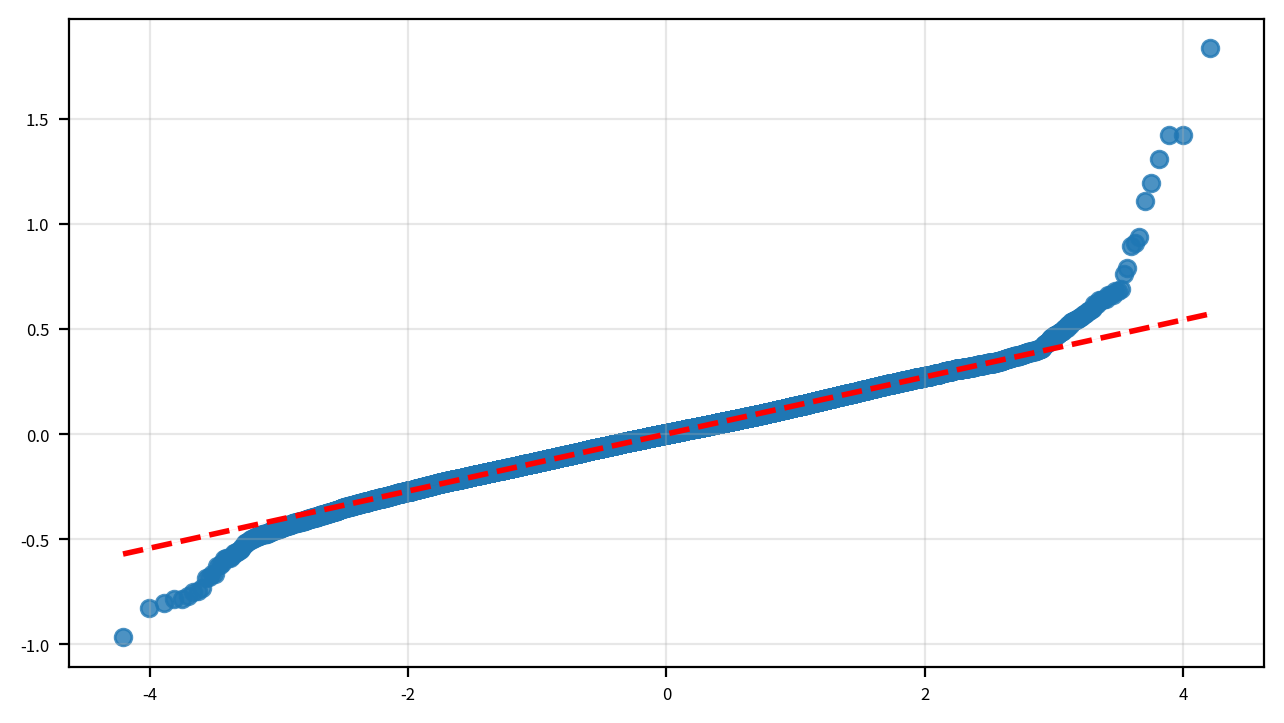

루트 1MSE 구간에 포함된 잔차 비율: 11.73%
루트 2MSE 구간에 포함된 잔차 비율: 23.39%
루트 3MSE 구간에 포함된 잔차 비율: 33.84%


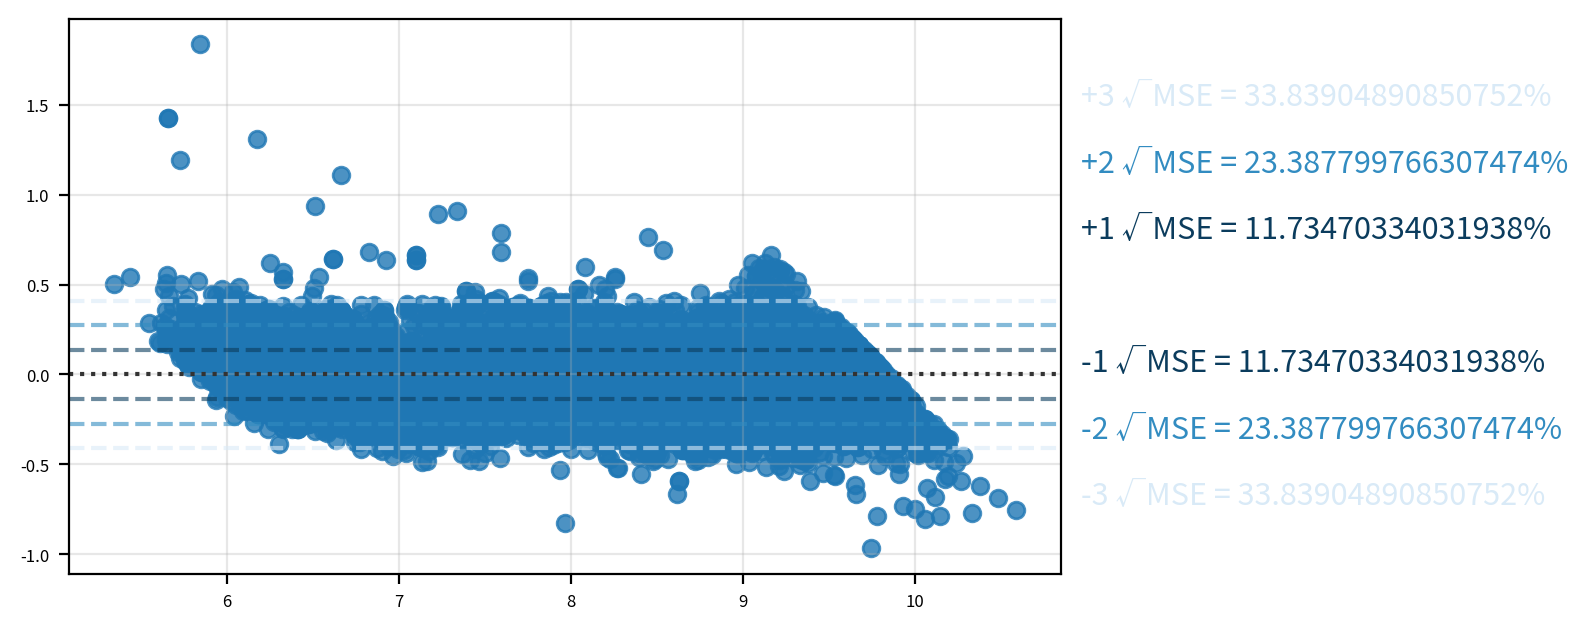

🎯 잔차의 정규성, 등분산성, 독립성 검정
Anderson-Darling statistic: 21.1467, 5% 임계값: 0.7870
정규성 가정 위배 가능성이 있음 (5% 유의수준)
Breusch-Pagan statistic: 99.489, p-value = 0.000
이분산성 존재(등분산 아님)
Durbin-Watson=1.252
잔차에 양(+)의 자기상관이 존재할 가능성 있음 (독립성 위반)
🎓 최종 결과 보고
log_price에 대하여 log_carat,cut_Good,cut_Premium,cut_Very Good,color_E,color_F,color_G,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2(으)로 예측하는 회귀분석을 실시한 결과, 이 회귀모형은 통계적으로 유의하다(F(17,53899)=1.725e+05, p <= 0.05).
log_carat의 회귀계수는 1.8801(p <= 0.05)로, log_price에 대하여 유의미한 예측변인인 것으로 나타났다.
cut_Good의 회귀계수는 -0.0680(p <= 0.05)로, log_price에 대하여 유의미한 예측변인인 것으로 나타났다.
cut_Premium의 회귀계수는 -0.0090(p <= 0.05)로, log_price에 대하여 유의미한 예측변인인 것으로 나타났다.
cut_Very Good의 회귀계수는 -0.0322(p <= 0.05)로, log_price에 대하여 유의미한 예측변인인 것으로 나타났다.
color_E의 회귀계수는 -0.0546(p <= 0.05)로, log_price에 대하여 유의미한 예측변인인 것으로 나타났다.
color_F의 회귀계수는 -0.0959(p <= 0.05)로, log_price에 대하여 유의미한 예측변인인 것으로 나타났다.
color_G의 회귀계수는 -0.1609(p <= 0.05)로, log_price에 대하여

In [17]:
# 데이터 입력
df=df1.copy()
yname='log_price'
df=df.drop(['carat','price','depth','table'], axis=1)

# 패키지 참조
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np
import pandas as pd
from pandas import DataFrame
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, pearsonr, spearmanr, probplot, shapiro, kstest, anderson
from statsmodels.formula.api import ols
from statsmodels.stats.api import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 그래프 초기화
my_dpi=200
font_path='../NotoSansKR-Regular.ttf'
fm.fontManager.addfont(font_path)
font_prop=fm.FontProperties(fname=font_path)
font_name=font_prop.get_name()
plt.rcParams['font.family']=font_name
plt.rcParams['font.size']=6
plt.rcParams['axes.unicode_minus']=False

# 다중선형회귀
df=pd.get_dummies(df, drop_first=True)
df=df.astype(float)
x=df.drop(yname, axis=1)
y=df[yname]
x_input=sm.add_constant(x)
fit=sm.OLS(y, x_input).fit()
tbl=fit.summary()
print('='*50)
print('📊 다중 선형 회귀')
print('='*50)
print(tbl)

def ols_report(tbl, data):
    xnames=[n for n in fit.model.exog_names if n!='const']
    indi_df=data.filter(xnames)
    variables=[]
    for i, v in enumerate(tbl.tables[1].data):
        name=v[0].strip()
        if name not in xnames:
            continue
        j=list(indi_df.columns).index(name)
        vif=variance_inflation_factor(indi_df,j)

        p=float(v[4].strip())
        stars=lambda p: (
            '***' if p<0.001 else
            '**' if p<0.01 else
            '*' if p<0.05 else
            ''
        )

        variables.append({
            '종속변수':yname,
            '독립변수':name,
            'B':v[1].strip(),
            '표준오차':v[2].strip(),
            'Beta':float(fit.params[name])*(data[name].std(ddof=1)/data[yname].std(ddof=1)),
            't':'%s%s'%(v[3].strip(), stars(p)),
            'p-value':p,
            '공차':1/vif,
            'vif':vif
        })

    rdf=DataFrame(variables)

    result_dict={}
    for i in [0,2]:
        for item in tbl.tables[i].data:
            n=len(item)
            for j in range(0, n, 2):
                key=item[j].strip()[:-1]
                value=item[j+1].strip()
                if not key or not value:
                    continue
                result_dict[key]=value
    
    result_report=f'R({result_dict['R-squared']}), R²({result_dict['Adj. R-squared']}), F({result_dict['F-statistic']}), 유의확률({result_dict['Prob (F-statistic)']}), Durbin-Watson({result_dict['Durbin-Watson']})'

    tpl='%s에 대하여 %s(으)로 예측하는 회귀분석을 실시한 결과, 이 회귀모형은 통계적으로 %s(F(%s,%s)=%s, p %s 0.05).'
    model_report=tpl%(
        rdf['종속변수'][0],
        ','.join(list(rdf['독립변수'])),
        '유의하다' if float(result_dict['Prob (F-statistic)'])<=0.05 else '유의하지 않다',
        result_dict['Df Model'],
        result_dict['Df Residuals'],
        result_dict['F-statistic'],
        '<=' if float(result_dict['Prob (F-statistic)'])<=0.05 else '>'
    )

    variable_reports=[]
    s='%s의 회귀계수는 %s(p %s 0.05)로, %s에 대하여 %s 예측변인인 것으로 나타났다.'

    for i in rdf.index:
        row=rdf.iloc[i]
        variable_reports.append(s%(row['독립변수'],
                                   row['B'],
                                   '<=' if float(row['p-value'])<0.05 else '>',
                                   row['종속변수'],
                                   '유의미한' if float(row['p-value'])<0.05 else '유의하지 않은'))
        
    return rdf, result_report, model_report, variable_reports

while True:
    rdf, r, m, v=ols_report(tbl, df)
    if rdf['vif'].max()>=10:
        df=df.drop(rdf[rdf['vif']==rdf['vif'].max()]['독립변수'], axis=1)
        x=df.drop(yname, axis=1)
        y=df[yname]
        x_input=sm.add_constant(x)
        fit=sm.OLS(y, x_input).fit()
        tbl=fit.summary()
    else:
        break

# p-value 무효값 제외
xnames=list(rdf[rdf['p-value']>0.05]['독립변수'])
df=df.drop(xnames, axis=1)
x=df.drop(yname, axis=1)
y=df[yname]
x_input=sm.add_constant(x)
fit=sm.OLS(y, x_input).fit()
tbl=fit.summary()
rdf, r, m, v=ols_report(tbl, df)
print('='*50)
print('✅ 분석 결과')
print('='*50)
display(rdf)
print(m)

# 잔차 검정
print('='*50)
print('📕 선형성 검정')
print('='*50)
reset_res=linear_reset(fit, power=2, use_f=True)
print(f'RESET F-statistic: {reset_res.fvalue:.4f}')
print(f'p-value: {reset_res.pvalue:.4f}')
if reset_res.pvalue<0.05:
    print('선형성/기능형 위배 가능성이 있음 (5% 유의수준)')
else:
    print('선형성 가정 위배 근거 없음 (5% 유의수준)')

(x,y),_=probplot(fit.resid)
width_px=1280
height_px=720
rows=1
cols=1
figsize=(width_px/my_dpi, height_px/my_dpi)
fig, ax=plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
sb.regplot(x=x, y=y, line_kws={'color':'red', 'linestyle':'--', 'linewidth':2})
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

r=fit.resid
mse_sq=fit.mse_resid
mse_root=np.sqrt(mse_sq)
colors=['#0B3C5D', '#328CC1', '#D9EAF7']
r1=r[(r>-mse_sq)&(r<mse_sq)].count()/r.count()*100
r2=r[(r>-2*mse_sq)&(r<2*mse_sq)].count()/r.count()*100
r3=r[(r>-3*mse_sq)&(r<3*mse_sq)].count()/r.count()*100
mse_r=[r1,r2,r3]
print(f'루트 1MSE 구간에 포함된 잔차 비율: {r1:.2f}%')
print(f'루트 2MSE 구간에 포함된 잔차 비율: {r2:.2f}%')
print(f'루트 3MSE 구간에 포함된 잔차 비율: {r3:.2f}%')
width_px=1280
height_px=720
rows=1
cols=1
figsize=(width_px/my_dpi, height_px/my_dpi)
fig, ax=plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
sb.residplot(x=fit.fittedvalues, y=fit.resid)
ax.grid(True, alpha=0.3)
for i, c in enumerate(colors):
    k=i+1
    y_pos=k*mse_root
    ax.axhline(y=y_pos, color=c, linestyle='--', alpha=0.6)
    ax.axhline(y=-y_pos, color=c, linestyle='--', alpha=0.6)
    ax.text(x=1.02, y=0.5+0.12*k,
            s=f'+{k} √MSE = {mse_r[i]}%',
            transform=ax.transAxes,
            ha='left', va='center', fontsize=11, color=c)
    ax.text(x=1.02, y=0.5-0.12*k,
            s=f'-{k} √MSE = {mse_r[i]}%',
            transform=ax.transAxes,
            ha='left', va='center', fontsize=11, color=c)
plt.show()
plt.close()

# 잔차의 정규성, 등분산성, 독립성 검정
print('='*50)
print('🎯 잔차의 정규성, 등분산성, 독립성 검정')
print('='*50)
if len(origin)<5000:
    method='Shapiro-Wilk'
    s, p=shapiro(fit.resid)
    print(f'{method} statistic: {s:.4f}, p-value: {p:.4f}')
    violated=p<0.05
else:
    method='Anderson-Darling'
    ad_res=anderson(fit.resid, dist='norm')
    crit_levels=ad_res.significance_level.tolist()
    crit_values=ad_res.critical_values.tolist()
    crit_5=crit_values[crit_levels.index(5.0)] if 5.0 in crit_levels else None
    print(f'{method} statistic: {ad_res.statistic:.4f}, 5% 임계값: {crit_5:.4f}')
    violated=crit_5 is not None and ad_res.statistic>crit_5
print('정규성 가정 위배 가능성이 있음 (5% 유의수준)' if violated else '정규성 가정 위배 근거 없음 (5% 유의수준)')

names=['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_test=het_breuschpagan(fit.resid, fit.model.exog)
bp=DataFrame(bp_test, index=names, columns=['value'])
p_bp=bp.loc['F p-value', 'value']
print(f'Breusch-Pagan statistic: {bp.loc['F Statistic', 'value']:.3f}, p-value = {p_bp:.3f}')
print(f'{'이분산성 존재(등분산 아님)' if p_bp<=0.05 else '등분산성 만족'}')

dw=durbin_watson(fit.resid)
if 1.5<=dw<=2.5:
    interpretation='잔차는 독립성을 만족함 (자기상관 없음)'
elif dw<1.5:
    interpretation='잔차에 양(+)의 자기상관이 존재할 가능성 있음 (독립성 위반)'
else:
    interpretation='잔차에 음(-)의 자기상관이 존재할 가능성 있음 (독립성 위반)'
print(f'Durbin-Watson={dw:.3f}\n{interpretation}')

# 최종 결과 보고
print('='*50)
print('🎓 최종 결과 보고')
print('='*50)
print(m)
print('\n'.join(v))

위의 분석에서 유효한 변수라고 판단되었던 log_carat, x, y, z, cut, color, clarity 변수들로 선형회귀모델을 분석한 결과,  
x y z는 유효하지 않은 변수로 판정되어서 모델에서 빠지게 되었다.  

log_carat과 clarity 변수는 log_price에 대해 유의미한 양(+)의 상관관계를 가지고 있는 것으로 보이고,  
cut과 color 변수는 log_price에 대해 유의미한 음(-)의 상관관계를 가지고 있는 것으로 보인다.  

또한 Q-Q 플롯과 잔차의 시각화를 통해 잔차의 분포도를 살펴보았는데, 몇 가지 특이점들로 인해 잔차의 선형성이 위배되는 모습을 보여주고 있다.  
이 모델을 개선하려면 로그 대신 제곱근을 취하거나, 조금 더 정제된 이상치의 전처리 과정이 선행되어야할 것이다.

## 🎯미션12. 같은 carat을 가진 두 다이아몬드의 가격이 다른 이유는?

In [18]:
my_dia1={'log_carat':0.5, 'cut_Good':0, 'cut_Premium':1, 'cut_Very Good':0, 'color_E':1, 'color_F':0, 'color_G':0, 'color_H':0, 'color_I':0, 'color_J':0, 'clarity_IF':1, 'clarity_SI1':0, 'clarity_SI2':0, 'clarity_VS1':0, 'clarity_VS2':0, 'clarity_VVS1':0, 'clarity_VVS2':0}

my_dia2={'log_carat':0.5, 'cut_Good':0, 'cut_Premium':0, 'cut_Very Good':0, 'color_E':1, 'color_F':0, 'color_G':0, 'color_H':0, 'color_I':0, 'color_J':0, 'clarity_IF':0, 'clarity_SI1':0, 'clarity_SI2':0, 'clarity_VS1':0, 'clarity_VS2':0, 'clarity_VVS1':0, 'clarity_VVS2':0}

x_new=DataFrame([my_dia1])
x_new_input=sm.add_constant(x_new, has_constant='add')
myresult1=fit.predict(x_new_input)
print('Premium컷 E컬러 IF등급 다이아몬드 가격 :', myresult1.iloc[0])

y_new=DataFrame([my_dia2])
y_new_input=sm.add_constant(y_new, has_constant='add')
myresult2=fit.predict(y_new_input)
print('Ideal컷 E컬러 I1등급 다이아몬드 가격 :', myresult2.iloc[0])

Premium컷 E컬러 IF등급 다이아몬드 가격 : 10.001256373900421
Ideal컷 E컬러 I1등급 다이아몬드 가격 : 8.85247670330595


log_carat 변수를 통제한 상태에서, "다이아의 컷 품질", "다이아의 색상 등급", "다이아의 투명도 등급"을 조정하였을 때 다이아의 가격이 변동한 것을 볼 수 있다.  
위의 분석 모델과 예시 데이터 들을 통하여 우리는 다이아의 가격을 결정짓는 데에 유의미한 영향을 끼치는 요소는 컷 품질, 색상 등급, 투명도 등급임을 알 수 있었다.  
다만 이 분석을 통해서는 다이아 그 자체의 가치만 확인할 수 있고, 현재 국제 경제 사정에 따른 변화를 예측하기는 힘들다.  
앞으로 더 다양한 변수 데이터 수집을 통하여 다이아몬드의 가격 요인을 더욱 명확하게 파악할 수 있고, 이를 통해 다이아몬드의 가격 변동을 확실하게 예측할 수 있을 것이다.